In [117]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from app.utils.gpt_parser import canonical_portfolio
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from app.core.calculations.returns.calculator import ReturnsCalculator, PortfolioReturnsCalculator
from app.core.calculations.performance.calculator import PerformanceCalculator
from app.core.calculations.risk.calculator import RiskCalculator
from app.repositories.price_data import get_price_data_daily, get_dividends_series
from app.repositories.price_data import fetch_bulk_price_data_for_tickers
import matplotlib.pyplot as plt
# Fetch industry and sub-industry data for all tickers
from app.db.core.db_config import MarketSession, ProphitAltsSession
from app.db.core.market_data_models import Ticker
from app.core.agentic_framework.tool_lib.portfolio_tools.performance import calculate_portfolio_performance



In [118]:
x = [
  {
    "ticker": "MO",
    "position": "long",
    "thesis": "Altria is a value-driven defensive holding in the consumer staples sector. It offers a trough multiple, resilient pricing power, and robust free cash flow conversion even in challenging regulatory environments. The company’s menthol rule was withdrawn, nicotine cap timelines have been extended, and the market over-discounts US combustibles risk. Consistent dividend growth, stable FCF margins, and cash returns make MO particularly attractive as the sector faces uncertain macro and declining appetite for high-beta exposures. Despite low beta portfolio dynamics, MO anchors yield and stability.",
    "key_drivers": "1) High and stable dividend yield; 2) Resilient FCF margins; 3) Defensive market position in US tobacco; 4) Regulatory relief on menthol/nicotine rules; 5) Healthy margin stability; 6) Over-discounted risk provides margin of safety.",
    "allocation": 0.072
  },
  {
    "ticker": "TAP",
    "position": "long",
    "thesis": "Molson Coors presents a deep-value recovery and seasonal inflection. With stable balance sheet and operational cash flows, TAP is currently at a margin/earnings inflection point after a period of negative sentiment. Margin recovery, innovation cycles, and disciplined cost management position it for sustainable outperformance. The stock benefits from seasonal demand tailwinds, underappreciated earnings, and relatively low correlation to other beverage names, making it a portfolio diversifier.",
    "key_drivers": "1) EPS/margin inflection and stabilization; 2) Cost optimization and operational leverage; 3) Seasonal demand tailwinds; 4) Distribution and shelf-space moat; 5) Underestimated cash conversion in deep value segment.",
    "allocation": 0.069
  },
  {
    "ticker": "ACI",
    "position": "long",
    "thesis": "Albertsons is a contrarian, fundamental recovery idea in US grocery retail, with improving operating margins, resilient traffic, and an attractive FCF yield. Loyalty/data leverage and improving supply chain execution support margin expansion and a re-rating opportunity. The public-private arbitrage and overhang concerns create relative mispricing versus the underlying fundamentals.",
    "key_drivers": "1) Operating margin recovery; 2) Under-discounted loyalty/data leverage; 3) Defensive traffic trends and private label tailwind; 4) Supply chain self-help/cost resets; 5) Balance sheet improvement.",
    "allocation": 0.066
  },
  {
    "ticker": "HSY",
    "position": "short",
    "thesis": "Hershey faces multiquarter earnings/margin compression from sustained cocoa price spikes, with operational/labor cost risk and EU traceability regulation adding to cost complexity. Peer re-rating risk high, as the premium multiple is not sustainable in a deteriorating margin environment, and consensus remains stubbornly optimistic.",
    "key_drivers": "1) Sustained high cocoa input costs; 2) Margin compression risk; 3) Premium valuation into negative momentum; 4) Regulatory cost overlays (EU); 5) Channel compliance expense risk; 6) Category cyclicality with slowing demand.",
    "allocation": 0.055
  },
  {
    "ticker": "CAG",
    "position": "short",
    "thesis": "Conagra Brands shows visible deceleration in both earnings quality and price momentum. While the valuation screens cheap, multiple years of margin compression, diluted EPS growth, and CEO transition headwinds expose the name to near-term earnings misses and consensus estimate resets.",
    "key_drivers": "1) Weak/reversing EPS growth; 2) Operating margin contraction; 3) Segment share loss risk; 4) Guide risk from commodity pass-through lag; 5) CEO/executive transition overhang.",
    "allocation": 0.052
  },
  {
    "ticker": "KO",
    "position": "long",
    "thesis": "Coca-Cola remains an all-weather play with superior global shelf presence, pricing power, and a resilient innovation cycle that drives premium at-scale. It is slower-growth but offers defensible returns in volatile macro conditions; the company’s cost control, international expansion, and pricing/case-mix superiority are underappreciated in the current tape.",
    "key_drivers": "1) Earnings defensiveness; 2) Shelf-space/distribution moat; 3) Operational leverage through bottlers; 4) Strong pricing power; 5) Cost controls versus peers; 6) Resilient margin expansion.",
    "allocation": 0.058
  },
  {
    "ticker": "STZ",
    "position": "short",
    "thesis": "Constellation Brands is approaching a negative inflection after peakish margin/return years. Execution missteps, regulatory risk (TTB developments), rising leverage, and recent channel performance highlight the risk of multiple compression. Momentum and sell-side ratings have rolled over as market begins to price in regulatory liabilities and weak RTD performance.",
    "key_drivers": "1) Regulatory and TTB channel risk; 2) Margin/return compression; 3) Softening momentum and ratings; 4) Leverage increase and peakish margins; 5) Earnings quality and guidance risk.",
    "allocation": 0.052
  },
  {
    "ticker": "BG",
    "position": "long",
    "thesis": "Bunge is a fundamental commodity business with normalized cash flows, a disciplined hedging program, and strong comparative advantage in ag origination/processing. The shares discount mid-cycle economics and offer a margin of safety. Bunge’s capital returns and cost control insulate it from macro shocks.",
    "key_drivers": "1) Normalized agricultural margins and processing; 2) Disciplined hedging and capital returns; 3) Mid-cycle discount vs. ag peers; 4) Supply chain traceability advantage.",
    "allocation": 0.066
  },
  {
    "ticker": "ELF",
    "position": "short",
    "thesis": "e.l.f. Beauty’s premium growth and best-in-class execution are increasingly offset by tariff headwinds, high China sourcing exposure, pricing action fatigue, and high valuation. The Rhode integration and rising execution risks exaggerate the skew to the downside at current levels. Despite growth accolades, the market is overpaying for risky growth.",
    "key_drivers": "1) Tariff and China sourcing risk; 2) High valuation and negative momentum; 3) Integration and supply chain execution risk; 4) Pricing action fatigue; 5) Headline risk.",
    "allocation": 0.052
  },
  {
    "ticker": "KMB",
    "position": "long",
    "thesis": "Kimberly-Clark trades at a discount to global household peers, has defensive end-markets, and is at a margin inflection (pulp costs relief, cost actions). GM/FCF normalization is underappreciated, and the below-peer valuation screens attractive for income and growth. Payout safety is high.",
    "key_drivers": "1) GM improvement with pulp/cost relief; 2) Dividend security; 3) Market share gains on innovation cycle; 4) Under-discounted recovery vs. defensive staples peer set.",
    "allocation": 0.065
  },
  {
    "ticker": "EPC",
    "position": "long",
    "thesis": "Edgewell Personal Care is a contrarian value long with self-help margin repair, low tariff risk, and brand momentum (Hawaiian Tropic plus international brands). Sun/razor product and channel innovations set up multi-quarter profit expansion. Recent A&P effectiveness and portfolio stability drive multi-cycle upside as input normalization sets in.",
    "key_drivers": "1) Margin repair and self-help; 2) Brand and international stability; 3) Portfolio innovation effectiveness; 4) Tariff-resilient mix; 5) ROIC normalization potential.",
    "allocation": 0.064
  },
  {
    "ticker": "DG",
    "position": "long",
    "thesis": "Dollar General is positioned well for consumer trade-down and value-seeking behavior. Supply chain self-help and improved shrink/cost discipline are catalyzing a multi-year margin recovery. Rising private label traction and consistent market share gains support the long thesis.",
    "key_drivers": "1) Margin/volume recovery; 2) Consumer trade-down traffic tailwinds; 3) Supply chain and shrink optimization; 4) Private label expansion.",
    "allocation": 0.06
  },
  {
    "ticker": "RLX",
    "position": "long",
    "thesis": "RLX Technology is a contrarian deep value/enabling technology holding within China ENDS, with a cash-rich balance sheet and signs of top-line and EBTIDA improvement. Its net cash balance and resilience through channel volatility warrant a valuation re-rating versus global peers.",
    "key_drivers": "1) Net cash balance; 2) Improving top-line and earnings; 3) Constructive analyst revisions; 4) Dividend reinstatement and low valuation against global staples.",
    "allocation": 0.054
  },
  {
    "ticker": "IPAR",
    "position": "long",
    "thesis": "Inter Parfums is a stable compounder in prestige fragrance, with pricing power, asset-light execution, and solid tariff planning. Coach licensing extension, regional/international localization, and mid-single pricing offset tariffs. Strong FCF yield and attractive value versus peer luxury brands.",
    "key_drivers": "1) Franchise/Coach license security; 2) Tariff/currency risk management; 3) Strong FCF and value vs. luxury; 4) Localization and stable licensing income; 5) Defensive demand visibility.",
    "allocation": 0.053
  },
  {
    "ticker": "PPC",
    "position": "long",
    "thesis": "Pilgrim's Pride commands value in early-cycle poultry recovery as feed costs normalize from 2022 peaks and mix improves across key channels. The market embeds too conservative spread expectations. Strong cash generation and disciplined cost pass-through ability make PPC a classic mean reversion story.",
    "key_drivers": "1) Feed cost normalization; 2) Channel mix improvement; 3) Return to mean margin expansion; 4) Cash flow discipline.",
    "allocation": 0.05
  },
  {
    "ticker": "GIS",
    "position": "long",
    "thesis": "General Mills is a defensive staple at an earnings trough; volume stabilization and SKU rationalization set up EBIT mean reversion upside, while defensive brands and cash conversion add protection in a risk-off environment.",
    "key_drivers": "1) Margin stabilization; 2) Value-savvy operational play; 3) EBIT mean reversion; 4) Resilient cash conversion and dividend.",
    "allocation": 0.048
  },
  {
    "ticker": "ODD",
    "position": "long",
    "thesis": "Oddity Tech is a high-growth DTC platform with a differentiated tech moat and cash generation, supported by declining tariff risk and international growth. Consistent earnings surprises and new brand launches provide catalyst-driven upside.",
    "key_drivers": "1) Consistent top-line beat; 2) Tech/DTC moat; 3) Brand pipeline; 4) International expansion opportunity; 5) Resilient cash metrics.",
    "allocation": 0.046
  },
  {
    "ticker": "REYN",
    "position": "long",
    "thesis": "Reynolds Consumer Products offers discounted FCF generation and household packaging with stabilizing costs. Inventory normalization and deleveraging set up sentiment recovery; the market underestimates FCF conversion.",
    "key_drivers": "1) Discounted FCF yield; 2) Stabilizing resin/input costs; 3) Deleveraging; 4) Household packaging recovery; 5) Defensive end-markets.",
    "allocation": 0.044
  },
  {
    "ticker": "TGT",
    "position": "long",
    "thesis": "Target is recovering traffic, margins, and private label growth at a discounted multiple. Omnichannel and logistics investments are feeding through to improved profit compounding, while valuation offers safety margin against macro shocks.",
    "key_drivers": "1) Margin recovery; 2) Private label mix expansion; 3) Omnichannel profit lift; 4) Discounted multiple relative to recovery drivers.",
    "allocation": 0.042
  },
  {
    "ticker": "CELH",
    "position": "long",
    "thesis": "Celsius Holdings is the leading high-growth energy/functional beverage with strong sales/innovation cadence. KO partnership, increasing shelf-space, and volume outperformance outweigh timing risks, and pricing normalization is underappreciated.",
    "key_drivers": "1) Category innovation; 2) KO partnership leverage; 3) Distribution gains; 4) Cash flow conversion; 5) Demand durability.",
    "allocation": 0.041
  },
  {
    "ticker": "KLG",
    "position": "short",
    "thesis": "Kellogg's (Kellanova) faces cereal headwinds, rising promotional pressure, and competitive margin risk. Overvaluation relative to sector and secular mix erosion suggest re-rating risk.",
    "key_drivers": "1) Margin erosion in cereal segment; 2) Trade-down risk; 3) Promo/advertising cost drag; 4) Valuation premium unsustainable.",
    "allocation": 0.045
  },
  {
    "ticker": "CHD",
    "position": "short",
    "thesis": "Church & Dwight is overvalued relative to growth and ROIC, with regulatory and promo intensity eating into margin and raising estimate risk. The quality premium is not justifiable and is exposed to mean reversion.",
    "key_drivers": "1) Valuation premium; 2) ROIC/gloss fading; 3) Regulatory risk; 4) Promo/competition cost increases; 5) Estimate revision risk.",
    "allocation": 0.041
  },
  {
    "ticker": "FRPT",
    "position": "short",
    "thesis": "Freshpet's valuation remains demanding with thin profitability and sensitivity to consumer trade-down. Execution bar is high for sustained margin expansion; any slip could result in sharp multiple compression.",
    "key_drivers": "1) Valuation/expectations risk; 2) Thin operating margins; 3) Promo-creep risk; 4) Category demand sensitivity.",
    "allocation": 0.04
  },
  {
    "ticker": "CLX",
    "position": "short",
    "thesis": "Clorox’s leverage, channel risk, and persistent premium valuation do not match industry growth or cost risk. Elevated leverage and input volatility expose it to sentiment reversals as mean reversion trade.",
    "key_drivers": "1) High leverage; 2) Elevated cost structure; 3) Channel margin risk; 4) Peer valuation compression.",
    "allocation": 0.04
  },
  {
    "ticker": "SFM",
    "position": "short",
    "thesis": "Sprouts Farmers Market’s high-multiple organic/health-focused model faces the risk of consumer trade-down and valuation normalization as macro conditions and traffic headwinds challenge top-line compounding ability.",
    "key_drivers": "1) Trade-down dilution risk; 2) Macro/consumer traffic risk; 3) Promo spend volatility; 4) Premium valuation risk.",
    "allocation": 0.039
  },
  {
    "ticker": "COST",
    "position": "short",
    "thesis": "Costco has world-class logistics and loyalty but is priced for perfection. As pricing tailwinds fade, policy and macro headwinds (tariffs/import costs) create asymmetric downside for a still-rich multiple.",
    "key_drivers": "1) Peak valuation risk; 2) Macro sensitivity; 3) Policy/tariff risk; 4) Slowing pricing momentum and EPS growth.",
    "allocation": 0.039
  },
  {
    "ticker": "PFGC",
    "position": "short",
    "thesis": "Performance Food Group is stretched versus sector distributor peers; margin normalization and cost volatility threaten profit stability. Thin profitability and de-rating risk warrant a short position.",
    "key_drivers": "1) Valuation gap vs. peers; 2) Margin normalization; 3) Distribution cost volatility; 4) Execution bar risk.",
    "allocation": 0.037
  },
  {
    "ticker": "UTZ",
    "position": "short",
    "thesis": "UTZ Brands trades at a high multiple into intensifying promo pressure, private label risk, and earnings quality doubts. Mix/pricing risk and value-seeking consumer behavior challenge the company's margin stability.",
    "key_drivers": "1) Promotion intensity; 2) Private label market share threat; 3) Margin/volume execution risk; 4) Trade-spend challenge.",
    "allocation": 0.032
  },
  {
    "ticker": "TPB",
    "position": "short",
    "thesis": "Turning Point Brands trades at peak-like multiples after a sharp run, but fundamentals and earnings quality don't support the value. Regulatory and enforcement risk in specialty vape/smokeless further justify a re-rating.",
    "key_drivers": "1) Multiple expansion unsustainable; 2) Specialty category choppiness; 3) Enforcement risk (PMTA); 4) Channel normalization.",
    "allocation": 0.027
  },
  {
    "ticker": "OLPX",
    "position": "short",
    "thesis": "Olaplex is exposed to margin reset/rebuilding risk in the face of specialty retail volatility and brand/traffic momentum deterioration. Litigation and high volatility create uncertainty, and new products are unlikely to offset margin/traffic weakness.",
    "key_drivers": "1) Margin reset risk; 2) Litigation/brand challenge; 3) Specialty retail volatility; 4) High execution volatility.",
    "allocation": 0.025
  },
  {
    "ticker": "WDFC",
    "position": "short",
    "thesis": "WD-40, while iconic, is priced for perfection despite decelerating growth and FCF yield at discount to peer group. With growth normalizing and limited macro insulation, peer re-rating risk remains high.",
    "key_drivers": "1) Over-valuation; 2) Growth normalization; 3) Limited insulation from macro/fx; 4) FCF yield below peer staples.",
    "allocation": 0.025
  }]

x_two = {"portfolio": [{"ticker": "MO", "position": "long", "thesis": "Altria is a value-first compounder, with the market over-discounting regulatory/policy risks and nicotine volume declines. Durable free cash flow (9.7% yield), fortress balance sheet, and capital return discipline (leading payout yield) present asymmetric risk/reward. Regulatory catalysts (menthol delays, FDA pace, NJOY) remove existential clouds. Valuation is at cycle trough multiples (EV/EBIT, P/E), dividend is secure, and 3\u20136 month price momentum has inflected positively versus staples. Under-owned by institutions.", "key_drivers": "1) Durable high net cash flow and top sector dividend; 2) Regulatory overhang fading; 3) International/alternative category expansion; 4) Underlying technical reversal; 5) Below-peer valuation; 6) Payout commitment; 7) No major liquidity or accounting flags.", "allocation": 0.08}, {"ticker": "CAG", "position": "long", "thesis": "Conagra offers contrarian value, now in sequential margin recovery mode as cost and productivity initiatives take hold. Defensive volume base supports FCF conversion among the highest in staples. Valuation at deep cyclical discount, and execution bounce is underway. Analyst revision trend and below-consensus sentiment create re-rating tailwinds. Defensive, diversified brand shelf combined with visible operating leverage underlines resilience.", "key_drivers": "1) Margin repair; 2) Industry-leading FCF yield; 3) Defensive consumer base; 4) Sequential topline and bottom-line improvement; 5) Cheap versus history and peers; 6) Positive EPS revision; 7) Stable cash flow outlook.", "allocation": 0.07}, {"ticker": "KMB", "position": "long", "thesis": "Kimberly-Clark is a high-quality defensive core, with management\u2019s cost and innovation transformation apparent in margin expansion and EPS beats. Defensive product mix, strong dividend continuity (19 years) and improved execution offset FX and mature market headwinds. Valuation is discounted to peers on EV/EBIT, and evidence of gross margin widening is confirmed. Short-term price momentum is soft, but long-term trend is constructive.", "key_drivers": "1) Gross margin expansion; 2) Dividend sustainability; 3) Transformation benefits; 4) Net cash generation; 5) FX/revenue risks flagged; 6) Analyst upgrades.; 7) Brand premium; 8) Positive Q3 2024 earnings surprise.", "allocation": 0.065}, {"ticker": "TGT", "position": "long", "thesis": "Target is executing a defensive turn, gaining back store traffic and driving up private label mix post-2023 drawdown. Margin and EPS bottomed out, with omnichannel and inventory optimization tilting outlook back to growth. Market and analyst consensus is still cautious, supporting continued multiple expansion. Product/format moat is robust, and valuation is below historical average with upside if margin improvement persists.", "key_drivers": "1) Margin/traffic upturn; 2) Best-in-class private label; 3) Inventory/tech investment; 4) Store rebound; 5) Stable consumer demand profile; 6) Valuation discount versus history; 7) EPS growth re-acceleration.", "allocation": 0.07}, {"ticker": "BG", "position": "long", "thesis": "Bunge is an underpriced staple, benefitting from disciplined hedging, capital returns, and cost controls. Cycle trough dynamics are over-discounted, and international origination/execution provides steady FCF. Export and grain supply chain leadership position BG for a multi-quarter re-rate, with an improving outlook for EM demand, while valuation remains attractive to sector and historical averages.", "key_drivers": "1) Defensive pricing power; 2) FCF durability; 3) Hedging/discipline; 4) Capital return focus; 5) Substantial exposure to EM agribusiness growth trends; 6) Trading below normalized FCF and earnings multiples.", "allocation": 0.06}, {"ticker": "BJ", "position": "long", "thesis": "BJ\u2019s Wholesale Club is a resilient consumer play, leveraging membership economics, private label strength, and a value-focused customer base. Outcompetes on traffic and conversion, and execution on store expansion supports a re-rating. Club-channel demand remains robust and price momentum, while below peak, is in a stable trading range.", "key_drivers": "1) Resilient membership economics; 2) Private label and traffic strength; 3) Value offering in inflationary periods; 4) Store/network expansion tailwind; 5) Positive club channel category fundamentals.", "allocation": 0.05}, {"ticker": "CCEP", "position": "long", "thesis": "Coca-Cola Europacific Partners offers premium bottling leverage, benefiting from shelf/distribution moat, margin stabilization, and international geography. Shares are discounted to KO, reflect macro headwinds, but earnings recovery and steady cash return profile make for defensive alpha. Rating trajectory is moving to positive.", "key_drivers": "1) Shelf space/distribution; 2) FCF stability; 3) Margin recovery; 4) Geographic diversification; 5) Below global peer valuation.", "allocation": 0.045}, {"ticker": "DG", "position": "long", "thesis": "Dollar General captures trade-down flows and low-income consumer, with operating repair initiatives now stabilizing execution risk. Store network, private label, and shrink/supply chain actions support near-term margin rebound and steady long-term EPS power. Shares screen at a deep discount to group, with confirmation of volume growth momentum in Q2/Q3 2024.", "key_drivers": "1) Trade-down exposure; 2) Margin repair trajectory; 3) Defensive customer; 4) Private label leverage; 5) Positive earnings confirmation; 6) Attractive valuation.", "allocation": 0.06}, {"ticker": "SAM", "position": "long", "thesis": "Boston Beer is a value/growth inflection play, with earnings/margin growth visible as supply chain volatility subsides. Cash-rich, low-leverage structure and innovation pipeline set up multi-year earnings compounding potential. Share price reflects underappreciated durability and cyclical trough conditions.", "key_drivers": "1) Innovation cycle tailwinds; 2) Positive margin inflection; 3) Cash returns optionality; 4) Earnings stability; 5) Category stability; 6) Valuation below peer group.", "allocation": 0.05}, {"ticker": "IPAR", "position": "long", "thesis": "Inter Parfums is a quality/luxury fragrance leader with asset-light earnings model and extended Coach license tailwind. Margins and FCF are well above sector, and international/localization efforts de-risk tariff exposure. Shares have rerating potential on continued margin recovery and positive cadence in product launch momentum.", "key_drivers": "1) Extended brand licenses; 2) Asset-light FCF model; 3) Pricing/channel control; 4) Tariff insulation; 5) Luxury subsector category momentum.", "allocation": 0.06}, {"ticker": "ODD", "position": "long", "thesis": "Oddity Tech is a high-growth DTC platform, leveraging data, product launch, and tech moats. Consistently beats and raises, manages tariffs, and international expansion is still underappreciated. Revenue/EPS cadence is strongest within peer set.", "key_drivers": "1) High-growth brand and product velocity; 2) International white space; 3) DTC margin structure; 4) Positive EPS/FCF revision trajectory.", "allocation": 0.055}, {"ticker": "EPC", "position": "long", "thesis": "Edgewell Personal Care is a value contrarian compounder executing self-help through productivity and A&P discipline. Balanced brand mix and successful international stablization set up a multi-quarter margin and share recovery.", "key_drivers": "1) Productivity/cost discipline; 2) Brand and international growth; 3) Resilient margin management; 4) EPS upside via self-help.", "allocation": 0.055}, {"ticker": "REYN", "position": "long", "thesis": "Reynolds is an FCF-rich household packaging leader with clear upside as resin and cost base stabilize. Shares trade at a FCF/margin discount; multi-quarter deleveraging and defensive moat support a re-rate.", "key_drivers": "1) Household penetration strength; 2) FCF margin recovery; 3) Cost inputs stabilizing; 4) Low-beta staple.", "allocation": 0.055}, {"ticker": "PPC", "position": "long", "thesis": "Pilgrim\u2019s Pride is an early-cycle poultry margin play, with feed cost normalization and improved category mix. Market is pricing trough dynamics while operating leverage is recovering.", "key_drivers": "1) Margin cycle tailwinds; 2) Global supply chain discipline; 3) Feed cost recovery; 4) Operating leverage.", "allocation": 0.055}, {"ticker": "KVUE", "position": "long", "thesis": "Kenvue is a defensive consumer health leader with cost and revenue growth levers (RGM), smart tariff absorption, and robust FCF. Balance sheet/cash improvement supports multiple expansion.", "key_drivers": "1) Cost and pricing levers; 2) Portfolio simplification; 3) Strategic channel diversity; 4) FCF yield; 5) Execution on channel compliance.", "allocation": 0.05}, {"ticker": "KDP", "position": "long", "thesis": "Keurig Dr Pepper is stabilizing after a margin/earnings trough, with diversified category exposure, manageable leverage, and undervalued margin normalization path. Steady shelf-space and brand equity defend EPS streams.", "key_drivers": "1) Multi-category shelf strength; 2) Underappreciated FCF recovery; 3) Manageable leverage and earnings base.", "allocation": 0.05}, {"ticker": "RLX", "position": "long", "thesis": "RLX Technology (China ENDS) is a contrarian deep value. Cash-rich, with improving revenue/earnings mix, regulatory headwinds now priced-in, and cash return now reinstated.", "key_drivers": "1) Large net cash position; 2) Small but constructive EPS base rebound; 3) Regulatory relief in China; 4) Deep value rerating potential.", "allocation": 0.045}, {"ticker": "CL", "position": "long", "thesis": "Colgate-Palmolive is a proven staple, offering high ROIC, global pricing power, and volume resiliency. Most recent trend is price-driven margin stabilization, with FCF and product innovation ongoing. Recent weakness offers entry opportunity.", "key_drivers": "1) Global pricing power; 2) Innovation cadence; 3) High quality/low volatility; 4) Positive long-term price and EPS growth roadmap.", "allocation": 0.045}, {"ticker": "HSY", "position": "short", "thesis": "Hershey is materially over-earning on post-pandemic pricing, facing operating margin compression via commodity (cocoa) cost spike and channel disruptions. Market is pricing in only a cyclical rollover, not full margin normalization. Technicals show persistent 3\u20136\u201312 month negative momentum.", "key_drivers": "1) Cocoa/commodity cost spike; 2) Channel disruption; 3) Margin mean reversion; 4) Negative multi-horizon technicals.", "allocation": 0.05}, {"ticker": "TPB", "position": "short", "thesis": "Turning Point Brands embodies high volatility and non-core tobacco/smokeless exposure. Share price has run well ahead of fundamentals, specialty vape/smokeless risk is underpriced, and regulatory risk is rising.", "key_drivers": "1) Regulatory headwinds; 2) Momentum stretched; 3) Execution risk on category channel normalization.", "allocation": 0.045}, {"ticker": "ELF", "position": "short", "thesis": "ELF Beauty trades at a premium valuation into tariff, supply chain, and China risk. Best-in-class execution, but category over-earning and input cost surge set up a de-rating. Momentum stretched versus historical baselines.", "key_drivers": "1) Valuation overextension; 2) China/tariff exposure; 3) Input cost and category mean revert; 4) Downside momentum break.", "allocation": 0.05}, {"ticker": "UTZ", "position": "short", "thesis": "UTZ Brands is a premium-multiple, premium snack name at risk from private label encroachment and aggressive promotion. Margins and revenue composition are deteriorating at the margin, with technicals negative and FCF/quality declining versus previous cycles.", "key_drivers": "1) Margin deterioration; 2) Aggressive promotion; 3) Private label threat; 4) Negative multi-horizon price momentum.", "allocation": 0.05}, {"ticker": "KLG", "position": "short", "thesis": "WK Kellogg faces secular headwinds in cereal, with high private label threat, SKU pruning, and promo normalization. Near-term execution risk exists on cost actions and retailer shelf resets.", "key_drivers": "1) Secular cereal headwinds; 2) Private label risk; 3) Valuation premium; 4) Shrinking margins; 5) Technicals negative.", "allocation": 0.05}, {"ticker": "COST", "position": "short", "thesis": "Costco is one of the highest quality operators, but valuation is extended far above staples benchmarks. Macro headwinds and policy/tax debate limit upside. The premium is above even historical market-crisis precedents.", "key_drivers": "1) Valuation excess; 2) Macro and tax headwinds; 3) Defensive category rotation.", "allocation": 0.05}, {"ticker": "CELH", "position": "short", "thesis": "Celsius Holdings trades at an extreme growth/momentum premium relative to normalization of category sales and promo reset. Competition risk and shelf reset are under-appreciated. Downside technicals.", "key_drivers": "1) Growth normalization; 2) Category margin mean reversion; 3) Shelf reset competition.", "allocation": 0.045}, {"ticker": "CHD", "position": "short", "thesis": "Church & Dwight valuation implies perfection even as category mix and margin structure struggle. Elevated promo intensity, regulatory reformulation, and cost risks increase likelihood of earnings misses.", "key_drivers": "1) Margin compression; 2) Regulatory reformulation; 3) Earnings risk; 4) Promo/competition.", "allocation": 0.045}, {"ticker": "CLX", "position": "short", "thesis": "Clorox remains expensive, with negative FCF surprise risk and leverage/operational fragility. Margin recovery is priced-in, but channel and compliance costs persist.", "key_drivers": "1) Channel/compliance risk; 2) FCF risk; 3) Elevated leverage; 4) Weak technicals.", "allocation": 0.045}, {"ticker": "PFGC", "position": "short", "thesis": "Performance Food Group is overearning at cycle highs, with normalization and cost risk underappreciated. Thin profitability leaves downside risk to resets.", "key_drivers": "1) Margin normalization; 2) Cycle high earnings; 3) Thin profitability; 4) Relative group discount.", "allocation": 0.03}, {"ticker": "FRPT", "position": "short", "thesis": "Freshpet's premium pet food market positioning cannot justify valuation with thin profitability and category trade-down risk. High expectation bar for GM expansion not matched by evidence.", "key_drivers": "1) High valuation; 2) Promo and trade-down risk; 3) Margin pressure; 4) Execution bar.", "allocation": 0.03}, {"ticker": "OLPX", "position": "short", "thesis": "Olaplex faces margin reset and litigation execution risk. High volatility and specialty retail challenges persist, with strategy pivots unproven.", "key_drivers": "1) Margin reset; 2) Strategy shift; 3) Litigation risk; 4) Channel/trend risks.", "allocation": 0.03}, {"ticker": "SFM", "position": "short", "thesis": "Sprouts Farmers Market is a premium organic/health mix retailer vulnerable to trade-down and weakening momentum. Shares are rich versus grocery benchmarks with near-term earnings downside risk.", "key_drivers": "1) Trade-down risk; 2) Valuation premium; 3) Momentum deterioration; 4) Earnings risk.", "allocation": 0.03}, {"ticker": "WDFC", "position": "short", "thesis": "WD-40 Company\u2019s iconic brand cannot offset the premium valuation and growth deceleration. FCF yield is low compared to comparable staples, and technicals confirm mean reversion risk.", "key_drivers": "1) Growth/valuation mismatch; 2) FCF yield deterioration; 3) Negative technicals; 4) Earnings trend deceleration.", "allocation": 0.03}]}

x_three = [
  {
    "ticker": "ACI",
    "position": "long",
    "thesis": "Albertsons is a contrarian value play in grocery retail benefiting from strong loyalty/data leverage, cost containment, and digital/retail media expansion. The failed Kroger merger reset expectations to standalone upside with clear margin mean-reversion and value realization. Capital returns, stable market share, and analyst consensus (~42% upside) combine with resilient FCF.",
    "key_drivers": "1) Digital/retail media network buildout for high-margin sales; 2) Self-help cost cuts, improved productivity; 3) Loyalty/omnichannel leadership; 4) Undervalued on FCF yield, PE vs peers; 5) Positive analyst sentiment; 6) Dividend support",
    "allocation": 0.10
  },
  {
    "ticker": "BG",
    "position": "long",
    "thesis": "Bunge is a deeply discounted staple at a mid-cycle trough due to merger costs/volatility. Market over-discounts ag commodity normalization and Viterra merger drag; operational cash flow, capital discipline, and modest leverage support a sharp re-rating if ag spreads revert. Well-positioned for risk-managed ag processing.",
    "key_drivers": "1) Defensive FCF; 2) Ag cycles and merger cost mean-reversion; 3) Beat on EPS ex-merger items; 4) Capital returns; 5) Underappreciated platform",
    "allocation": 0.10
  },
  {
    "ticker": "CAG",
    "position": "long",
    "thesis": "Conagra offers the sector's top FCF yield and deep value catalyst as recently battered fundamentals stabilize. Management initiatives to repair margins, new product recovery in snacking, and an upcoming Q1 catalyst allow for asymmetric upside from a low PE base.",
    "key_drivers": "1) High FCF/low PE; 2) Earnings recovery catalyst; 3) High dividend; 4) Product innovation pipeline; 5) Downside protection in cost optimization if market weakens",
    "allocation": 0.09
  },
  {
    "ticker": "CCEP",
    "position": "long",
    "thesis": "Coca-Cola Europacific Partners is the bottler with both pricing flexibility and distribution resilience, generating consistent gross margin growth and supported by global shelf leverage. Margin trajectory outpaces peers, and high FCF drives downside resilience.",
    "key_drivers": "1) Global pricing power; 2) High FCF conversion; 3) Shelf-space/branding edge; 4) Above-peer margin expansion; 5) Defensive compounder",
    "allocation": 0.09
  },
  {
    "ticker": "DG",
    "position": "long",
    "thesis": "Dollar General is a trade-down winner, structurally supported by value-seeking consumer behavior and continuous network expansion. Strong performance vs retail peer group and robust SSS setup for a recovery rebound. Attractive normalization thesis from battered levels.",
    "key_drivers": "1) Defensive format; 2) SSS recovery; 3) Aggressive new store rollout; 4) Superior cost control; 5) Resilient demographic trend",
    "allocation": 0.10
  },
  {
    "ticker": "MO",
    "position": "long",
    "thesis": "Altria remains the sector's best defensive FCF generator, with regulatory risks discounted, a high and secure dividend yield, and improved momentum after menthol relief. Valuation is troughing and cash conversion is high, supporting portfolio risk-off and bond proxy appeal.",
    "key_drivers": "1) Regulatory relief; 2) High dividend; 3) Strong buyback; 4) Resilient pricing; 5) Low leverage",
    "allocation": 0.10
  },
  {
    "ticker": "ODD",
    "position": "long",
    "thesis": "Oddity Tech is a rare high-growth, modern DTC consumer platform with top-line expansion, robust technology/data moat, and unique brand creation. Growth >20% and operational agility are rare in this sector, giving non-staple risk/alpha exposure to the book.",
    "key_drivers": "1) DTC advantage, digital data/AI moat; 2) Consistent beat/raise cadence; 3) Durable >20% topline; 4) Strong cash conversion",
    "allocation": 0.10
  },
  {
    "ticker": "SAM",
    "position": "long",
    "thesis": "Boston Beer leverages an earnings/FCF inflection catalyst, cyclical new product innovation (hard seltzer/craft), and recently positive margin surprises. Market mispricing of mean-reverting profitability provides high alpha potential.",
    "key_drivers": "1) Earnings/OCF inflection; 2) Product innovation cycle; 3) Low leverage; 4) Core brand resilience",
    "allocation": 0.12
  },
  {
    "ticker": "XLY",
    "position": "long",
    "thesis": "XLY ETF is a tactical market sensitivity overlay used to structurally bring portfolio beta into range, providing cyclical discretionary exposure, reducing pairwise correlation, and boosting high alpha/market-capture scenarios as needed.",
    "key_drivers": "1) Market beta lever; 2) Cyclical discretionary exposure; 3) Reduces sector risk concentration; 4) Tactical rebalancing for plan compliance",
    "allocation": 0.10
  },
  {
    "ticker": "TGT",
    "position": "long",
    "thesis": "Target captures private label, omnichannel margin and traffic recovery, trading at a peer group discount. Recent SSS/traffic inflection and magnitude of SG&A control provide strong recovery upside as risk-on cyclical long.",
    "key_drivers": "1) Margin/traffic catalyst; 2) Private label and digital scale; 3) Peer discount; 4) SG&A magnitude",
    "allocation": 0.06
  },
  {
    "ticker": "COST",
    "position": "long",
    "thesis": "Costco market/club leader with superior economics, recurring revenue, high share of wallet, and defensive consumer health. Valuation is high but justified by profit path and optionality in global club rollout.",
    "key_drivers": "1) Recurring cash flow; 2) Market/club leader; 3) Defensive; 4) Global expansion path",
    "allocation": 0.06
  },
  {
    "ticker": "CHD",
    "position": "short",
    "thesis": "Church & Dwight is priced for perfection on PE but faces margin guidance risk, rising promotion intensity, and competitive catalysts. High valuation versus more durable peers with visible sector rotation risk.",
    "key_drivers": "1) High PE; 2) Margin guidance risk; 3) Increasing competition; 4) Negative momentum",
    "allocation": 0.06
  },
  {
    "ticker": "CLX",
    "position": "short",
    "thesis": "Clorox faces operational fragility, high channel/compliance cost pressure, and has a significant cyber-attack recovery overhang. Valuation remains high for trailing margin structure.",
    "key_drivers": "1) High peer premium; 2) Operational fragility post-cyber; 3) Compliance costs; 4) Defensive crowded trade unwinding",
    "allocation": 0.06
  },
  {
    "ticker": "CELH",
    "position": "short",
    "thesis": "Celsius is an extreme valuation mean reversion short with sector momentum fading and derating risk rising. High-volatility, sentiment-driven, and now negative technical signals.",
    "key_drivers": "1) Valuation derating; 2) Weakening sector momentum; 3) Sentiment fragility",
    "allocation": 0.07
  },
  {
    "ticker": "FRPT",
    "position": "short",
    "thesis": "Freshpet faces margin compression, premium valuation, and thin profitability, magnified by a shift in consumer spending to value. High promo exposure and risk of category volume slowdowns.",
    "key_drivers": "1) High PE/risk; 2) Promo-driven volume fragility; 3) Cost structure headwinds",
    "allocation": 0.05
  },
  {
    "ticker": "HSY",
    "position": "short",
    "thesis": "Hershey is at peak cocoa cost pain and margin compression stages, with valuation still not reflecting full multi-quarter downside. Channel complexity and weaker traceability add to downside risk.",
    "key_drivers": "1) Severe input spike; 2) Relative valuation premium; 3) Margin downside not fully recognized",
    "allocation": 0.07
  },
  {
    "ticker": "WMT",
    "position": "short",
    "thesis": "Walmart is a defensive giant showing peak valuation, with operating leverage now negative and difficult margin comp. Structural shift to lower-margin categories risks compression as trade-down reverses.",
    "key_drivers": "1) High sector-relative PE; 2) Margin compression; 3) Negative leverage; 4) Channel mix risk",
    "allocation": 0.06
  },
  {
    "ticker": "PEP",
    "position": "short",
    "thesis": "PepsiCo faces extended valuation, input/FX volatility and is under cyclical pressure relative to beverage and snack peers. High multiples reflect historical defensiveness, not likely to hold in mean-reverting regime.",
    "key_drivers": "1) High FX/input volatility; 2) Peer mean reversion catalyst; 3) Defensive multiple risk",
    "allocation": 0.05
  },
  {
    "ticker": "MNST",
    "position": "short",
    "thesis": "Monster’s premium multiple is now unsupported by normalization in category growth, rising competition, and sticky cost base; preferred cyclical short as defensive risk-off pivot unwinds.",
    "key_drivers": "1) Multiple derating; 2) Growth normalization; 3) Cost absorption",
    "allocation": 0.05
  },
  {
    "ticker": "DLTR",
    "position": "short",
    "thesis": "Dollar Tree faces negative operational leverage, margin pressure from aggressive expansion, and faces multiple compression on any execution miss in a tough macro backdrop.",
    "key_drivers": "1) Aggressive expansion cost; 2) Negative macro leverage; 3) Low-margin fragility",
    "allocation": 0.06
  }]

grok =[
  {
    "ticker": "MO",
    "position": "long",
    "thesis": "Altria Group (MO) is a high-conviction long position in the tobacco industry, selected for its resilient pricing power, durable free cash flow generation, and defensive characteristics in a volatile market. As a mature staple with limited growth but stable dividends and strong cash returns, MO fits the value-first strategy by offering a margin of safety through its dominant market share in U.S. combustibles, while transitioning to smoke-free products provides long-term catalysts. The position benefits from positive momentum confirmation and low relative volatility, making it a core holding for alpha generation in a low-beta portfolio.",
    "key_drivers": "FCF yield ~10% (strong cash conversion); EV/EBIT ~8x (discounted vs peers); P/E 9.5x vs EPS CAGR 2-3% (attractive valuation); catalysts: smoke-free growth (Njoy/On! brands), dividend yield 8%; risks: regulatory pressures on tobacco, slowing volume; momentum: r6_1 0.14, positive 3M confirmation.",
    "allocation": 0.065
  },
  {
    "ticker": "PPC",
    "position": "long",
    "thesis": "Pilgrim's Pride (PPC) represents a compelling value play in the protein processing sub-industry, backed by robust fundamentals including improving operational efficiency, margin expansion from cost controls, and a favorable supply-demand dynamic in poultry. The company's prudent capital allocation toward capacity optimization and debt reduction supports durable FCF, while recent performance indicates strong alpha potential. Selected for its positive momentum screen and high conviction, PPC enhances portfolio returns with a balanced risk profile in the food products sector.",
    "key_drivers": "FCF yield 8-9%; EV/EBIT 10x (undervalued vs history); P/E 12x vs EPS CAGR 15% (growth inflection); catalysts: protein demand growth, export expansion; risks: commodity price volatility, avian flu; momentum: strong positive r6_1 0.27, up-capture 43%.",
    "allocation": 0.08
  },
  {
    "ticker": "INGR",
    "position": "long",
    "thesis": "Ingredion Incorporated (INGR) is chosen for its essential role in food manufacturing with resilient margins from specialty ingredients and a healthy balance sheet enabling consistent dividends. The value-driven approach favors INGR's stable FCF generation and low debt levels, providing a defensive anchor in the agricultural products segment. Positive alpha from efficient operations and strategic acquisitions positions it well for near-term catalysts like demand for plant-based solutions, complemented by favorable momentum trends.",
    "key_drivers": "FCF yield 7%; EV/EBIT 11x; P/E 13x vs EPS CAGR 5%; catalysts: specialty ingredients growth; risks: input cost fluctuations; momentum: r6_1 0.09, positive screen.",
    "allocation": 0.07
  },
  {
    "ticker": "CL",
    "position": "long",
    "thesis": "Colgate-Palmolive (CL) embodies quality fundamentals with a strong brand moat, resilient margins exceeding 20%, and prudent capital allocation toward innovation in oral care. As a consumer staples leader, CL offers defensive stability with healthy FCF supporting buybacks and dividends, making it ideal for low-volatility alpha in household products. The position aligns with the strategy's emphasis on durable cash flows and is confirmed by positive momentum and consistent performance metrics.",
    "key_drivers": "FCF yield 6%; EV/EBIT 15x (premium justified); P/E 25x vs EPS CAGR 6%; catalysts: emerging market expansion; risks: competitive pressures; momentum: r6_1 0.18, strong up-capture.",
    "allocation": 0.07
  },
  {
    "ticker": "BJ",
    "position": "long",
    "thesis": "BJ's Wholesale Club (BJ) is a high-conviction retail long with strong membership economics, resilient sales growth, and efficient inventory management driving FCF. The value strategy highlights BJ's undervalued multiples relative to earnings growth from e-commerce and private label expansion, providing catalysts for outperformance. Selected for its positive momentum and moderate beta contribution, BJ diversifies the portfolio while targeting alpha through operational leverage.",
    "key_drivers": "FCF yield 5%; EV/EBIT 14x; P/E 20x vs EPS CAGR 10%; catalysts: membership fee increases; risks: consumer spending slowdown; momentum: r6_1 0.25, positive.",
    "allocation": 0.07
  },
  {
    "ticker": "TGT",
    "position": "long",
    "thesis": "Target Corporation (TGT) offers value in consumer staples distribution with improving margins from supply chain efficiencies and omnichannel growth. Fundamentals include healthy FCF from private labels and a balanced balance sheet, supporting the strategy's focus on resilient operations. Re-added for beta adjustment, TGT provides diversification and potential recovery catalysts amid positive consumer trends.",
    "key_drivers": "FCF yield 4%; EV/EBIT 12x; P/E 16x vs EPS CAGR 8%; catalysts: holiday sales recovery; risks: retail competition; momentum: r6_1 0.36, moderate.",
    "allocation": 0.065
  },
  {
    "ticker": "GIS",
    "position": "long",
    "thesis": "General Mills (GIS) is a defensive food products holding with stable FCF, resilient margins from branded staples, and prudent dividend policy. The value-first approach values GIS's low volatility and consistent cash returns, despite modest growth, as a core for portfolio stability. Re-included for beta contribution, it aligns with catalysts like cost savings and brand loyalty.",
    "key_drivers": "FCF yield 5.5%; EV/EBIT 13x; P/E 15x vs EPS CAGR 4%; catalysts: portfolio optimization; risks: input inflation; momentum: r6_1 0.21, stable.",
    "allocation": 0.06
  },
  {
    "ticker": "KMB",
    "position": "long",
    "thesis": "Kimberly-Clark (KMB) provides quality in household products with durable FCF from essential brands and margin resilience. The strategy favors KMB's strong balance sheet and capital returns via dividends, offering low-risk alpha in a defensive sector. Positive momentum and low drawdown make it a staple holding.",
    "key_drivers": "FCF yield 6%; EV/EBIT 14x; P/E 18x vs EPS CAGR 5%; catalysts: premium product pricing; risks: raw material costs; momentum: r6_1 0.09, positive.",
    "allocation": 0.06
  },
  {
    "ticker": "IPAR",
    "position": "long",
    "thesis": "Inter Parfums (IPAR) is selected for its growth in prestige fragrances with high conviction and value relative to earnings potential. Fundamentals show healthy margins and FCF from licensing deals, aligning with the strategy's blend of quality and growth. Momentum screen passed, providing diversification in personal care.",
    "key_drivers": "FCF yield 4%; EV/EBIT 12x; P/E 22x vs EPS CAGR 12%; catalysts: new brand launches; risks: luxury slowdown; momentum: r6_1 0.75, strong.",
    "allocation": 0.06
  },
  {
    "ticker": "KDP",
    "position": "long",
    "thesis": "Keurig Dr Pepper (KDP) combines value and quality in beverages with stable FCF from diversified portfolio and brand strength. The strategy highlights prudent allocation toward debt reduction and acquisitions, with catalysts in coffee/pod growth. Moderate momentum supports its role in balanced exposure.",
    "key_drivers": "FCF yield 5%; EV/EBIT 15x; P/E 20x vs EPS CAGR 7%; catalysts: pod market expansion; risks: competition; momentum: r6_1 0.11, positive.",
    "allocation": 0.06
  },
  {
    "ticker": "ODD",
    "position": "long",
    "thesis": "Oddity Tech (ODD) is a high-conviction growth play in digital personal care, leveraging data-driven marketing for margin expansion and FCF growth. The value strategy sees upside from scalable DTC model and low multiples vs high EPS growth, with catalysts in AI personalization. Positive momentum assumed enhances alpha potential.",
    "key_drivers": "FCF yield 6%; EV/EBIT 10x; P/E 25x vs EPS CAGR 25%; catalysts: international expansion; risks: e-commerce competition; momentum: assumed positive.",
    "allocation": 0.06
  },
  {
    "ticker": "BG",
    "position": "long",
    "thesis": "Bunge Global (BG) offers value in agricultural processing with strong FCF from commodity hedging and cost efficiencies. Fundamentals include healthy margins and balance sheet, fitting the strategy for resilient staples. Added for diversification and beta, with moderate momentum.",
    "key_drivers": "FCF yield 7%; EV/EBIT 9x; P/E 10x vs EPS CAGR 8%; catalysts: biofuel demand; risks: commodity volatility; momentum: r6_1 0.09, positive.",
    "allocation": 0.06
  },
  {
    "ticker": "EPC",
    "position": "long",
    "thesis": "Edgewell Personal Care (EPC) provides value in personal care essentials with improving FCF from brand rationalization and margin recovery. The strategy values its defensive nature and prudent capital use, with catalysts in e-commerce growth. Momentum screen supports inclusion.",
    "key_drivers": "FCF yield 5%; EV/EBIT 11x; P/E 14x vs EPS CAGR 10%; catalysts: product innovation; risks: category saturation; momentum: r6_1 0.32, positive.",
    "allocation": 0.055
  },
  {
    "ticker": "CAG",
    "position": "long",
    "thesis": "Conagra Brands (CAG) is a value-oriented food products play with potential margin mean reversion and FCF stability from portfolio simplification. Re-added for beta balance, it fits the fundamentals-driven approach with catalysts in snacking trends despite recent underperformance.",
    "key_drivers": "FCF yield 4.5%; EV/EBIT 12x; P/E 11x vs EPS CAGR 3%; catalysts: cost savings; risks: consumer health trends; momentum: r6_1 0.14, moderate.",
    "allocation": 0.055
  },
  {
    "ticker": "REYN",
    "position": "long",
    "thesis": "Reynolds Consumer Products (REYN) offers stable FCF in household packaging with resilient demand and margin discipline. The value strategy appreciates its low debt and dividend policy, providing defensive alpha. Positive momentum and low vol make it suitable.",
    "key_drivers": "FCF yield 5.5%; EV/EBIT 13x; P/E 18x vs EPS CAGR 5%; catalysts: e-commerce packaging; risks: raw material costs; momentum: r6_1 0.07, positive.",
    "allocation": 0.055
  },
  {
    "ticker": "KO",
    "position": "long",
    "thesis": "Coca-Cola (KO) is a cornerstone quality holding with unmatched brand moat, resilient margins >30%, and robust FCF supporting global expansion. The strategy favors KO's prudent allocation to dividends and buybacks, with catalysts in non-alcoholic beverages growth. Strong momentum confirms its role.",
    "key_drivers": "FCF yield 4%; EV/EBIT 18x; P/E 24x vs EPS CAGR 6%; catalysts: emerging markets; risks: sugar taxes; momentum: r6_1 0.12, positive.",
    "allocation": 0.055
  },
  {
    "ticker": "CCEP",
    "position": "long",
    "thesis": "Coca-Cola Europacific Partners (CCEP) extends KO's brand strength internationally with solid FCF and margin resilience. Selected for positive momentum and value vs peers, it diversifies geographically while aligning with the defensive staples focus.",
    "key_drivers": "FCF yield 5%; EV/EBIT 14x; P/E 15x vs EPS CAGR 7%; catalysts: Europe recovery; risks: FX volatility; momentum: r6_1 0.18, strong.",
    "allocation": 0.055
  },
  {
    "ticker": "HSY",
    "position": "short",
    "thesis": "Hershey (HSY) is shorted due to premium valuation and margin compression from cocoa costs, with deteriorating FCF amid slowing confection demand. High conviction short for mean reversion, as negative momentum and high EV/EBIT signal de-rating risk.",
    "key_drivers": "FCF yield 3%; EV/EBIT 20x (stretched); P/E 20x vs EPS CAGR 4% (overvalued); catalysts: none short-term; risks: pricing power; momentum: negative r6_1 -0.00, down-capture.",
    "allocation": 0.05
  },
  {
    "ticker": "CELH",
    "position": "short",
    "thesis": "Celsius Holdings (CELH) is a high-valuation growth name with momentum reversal risk after rapid rise, leading to FCF strain from expansion. Short for correction in beverages, given negative alpha and high volatility.",
    "key_drivers": "FCF yield 2%; EV/EBIT 25x (overvalued); P/E 50x vs EPS CAGR 50% (hype); catalysts: distribution limits; risks: sustained growth; momentum: r6_1 0.71, but reversing.",
    "allocation": 0.05
  },
  {
    "ticker": "EL",
    "position": "short",
    "thesis": "Estée Lauder (EL) faces headwinds from China slowdown and high leverage, eroding FCF and margins. Short position targets de-rating from premium multiples and negative momentum in luxury personal care.",
    "key_drivers": "FCF yield 3%; EV/EBIT 22x; P/E 30x vs EPS CAGR 5% (declining); catalysts: none; risks: brand recovery; momentum: negative r6_1 0.34.",
    "allocation": 0.05
  },
  {
    "ticker": "CHD",
    "position": "short",
    "thesis": "Church & Dwight (CHD) is shorted for slowing innovation and margin pressure in household, with FCF growth lagging peers. High conviction on valuation stretch and moderate negative momentum.",
    "key_drivers": "FCF yield 4%; EV/EBIT 18x; P/E 25x vs EPS CAGR 6%; catalysts: limited; risks: category leadership; momentum: r6_1 0.06, weak.",
    "allocation": 0.05
  },
  {
    "ticker": "STZ",
    "position": "short",
    "thesis": "Constellation Brands (STZ) carries regulatory and competition risks in alcohol, with FCF pressured by premium pricing challenges. Short for downside in beverages amid negative tilt.",
    "key_drivers": "FCF yield 4.5%; EV/EBIT 16x; P/E 20x vs EPS CAGR 7%; catalysts: cannabis exposure; risks: beer volume; momentum: r6_1 0.25, moderate negative.",
    "allocation": 0.05
  },
  {
    "ticker": "UTZ",
    "position": "short",
    "thesis": "Utz Brands (UTZ) shows weak FCF conversion and high multiples post-IPO, with risks from private label competition in snacks. Short for normalization given conviction and low momentum.",
    "key_drivers": "FCF yield 2.5%; EV/EBIT 15x; P/E 28x vs EPS CAGR 10%; catalysts: integration; risks: acquisition digestion; momentum: r6_1 0.09, weak.",
    "allocation": 0.05
  },
  {
    "ticker": "KLG",
    "position": "short",
    "thesis": "WK Kellogg (KLG) is shorted for post-spin challenges, margin erosion, and high debt impacting FCF. Value strategy targets overvaluation in packaged foods with negative momentum.",
    "key_drivers": "FCF yield 3%; EV/EBIT 12x; P/E 18x vs EPS CAGR 4%; catalysts: none; risks: cost cuts; momentum: r6_1 0.05, negative.",
    "allocation": 0.05
  },
  {
    "ticker": "CLX",
    "position": "short",
    "thesis": "Clorox (CLX) faces operational issues and margin pressure, leading to FCF weakness. Short for de-rating in household products given conviction and low returns.",
    "key_drivers": "FCF yield 4%; EV/EBIT 14x; P/E 20x vs EPS CAGR 5%; catalysts: limited; risks: brand strength; momentum: r6_1 0.14, weak.",
    "allocation": 0.05
  },
  {
    "ticker": "COCO",
    "position": "short",
    "thesis": "The Vita Coco Company (COCO) is overvalued post-growth phase with FCF strain from expansion, vulnerable to competition in beverages. Short for multiple compression amid conviction.",
    "key_drivers": "FCF yield 3.5%; EV/EBIT 20x; P/E 30x vs EPS CAGR 8%; catalysts: none; risks: health trends; momentum: assumed negative.",
    "allocation": 0.05
  },
  {
    "ticker": "PFGC",
    "position": "short",
    "thesis": "Performance Food Group (PFGC) has moderate returns but high debt and cyclical risks in distribution. Short to balance exposure, given conviction and value tilt.",
    "key_drivers": "FCF yield 4%; EV/EBIT 11x; P/E 15x vs EPS CAGR 10%; catalysts: M&A; risks: foodservice volatility; momentum: r6_1 0.58, but short fit.",
    "allocation": 0.05
  },
  {
    "ticker": "USFD",
    "position": "short",
    "thesis": "US Foods (USFD) is shorted for overexposure in distribution and margin risks from inflation. Conviction highlights valuation relative to growth slowdown.",
    "key_drivers": "FCF yield 3%; EV/EBIT 13x; P/E 18x vs EPS CAGR 9%; catalysts: none; risks: scale advantages; momentum: r6_1 0.69, reversing.",
    "allocation": 0.05
  },
  {
    "ticker": "COTY",
    "position": "short",
    "thesis": "Coty (COTY) faces weak FCF and high leverage in personal care, with risks from luxury slowdown. Short for de-rating given negative alpha and momentum.",
    "key_drivers": "FCF yield 2%; EV/EBIT 16x; P/E 25x vs EPS CAGR 6%; catalysts: limited; risks: brand partnerships; momentum: negative r6_1 -0.12.",
    "allocation": 0.05
  },
  {
    "ticker": "PRMB",
    "position": "short",
    "thesis": "Premier Foods (PRMB) is added as a low-beta short in food products for balance, with stable but unexciting FCF and valuation providing mean reversion potential.",
    "key_drivers": "FCF yield 4%; EV/EBIT 12x; P/E 14x vs EPS CAGR 5%; catalysts: none; risks: UK market; momentum: assumed low positive for short.",
    "allocation": 0.05
  }]

g = [
  {
    "ticker": "AAPL",
    "position": "long",
    "thesis": "Coca-Cola Europacific Partners stands out as the premier beverage bottler in developed markets, delivering strong FCF, pricing power, and earnings visibility. CCEP's structural margin advantages (relative to peers and parent) and resilient mix/localization give it more upside as supply chains and categories normalize. Defensive, diversified, and poised for share gains with upside optionality if KO deploys innovative products regionally or leverages bottling integration.",
    "key_drivers": "Resilient developed market demand; high-margin geographically diversified business; shelf-space/distribution innovation with retailer partners; FCF compounding; margin option as costs normalize; defensive industry advantages in periods of volatility; upside from local SKU and brand extensions.",
    "allocation": 0.097
  },
  {
    "ticker": "NVDA",
    "position": "long",
    "thesis": "Ingredion provides both defensive and cyclical exposure via ingredient sourcing and specialty food inputs. Cost-plus through-cycle pricing, a high-mix specialty revenue stream, and exposure to regulatory/traceability upgrades (EUDR/FSMA) all position INGR for margin expansion and above-peer compounding. The current valuation does not reflect the stability of its product portfolio, improving FCF characteristics, or its optionality from mix or regulatory catalysts.",
    "key_drivers": "Specialty ingredients mix shift; regulatory traceability tailwinds; FCF conversion; cost-plus contracts; global market expansion; margin capture from capacity/tech upgrades.",
    "allocation": 0.097
  },
  {
    "ticker": "KO",
    "position": "long",
    "thesis": "Coca-Cola is the high-conviction liquid core holding for its global nonalcoholic beverage market leadership, outsized pricing power, structurally resilient FCF, and exceptional capital allocation. Despite its defensive staple status, recent pullback and strong analyst conviction signal a market under-appreciating Coca-Cola's continued global gains in emerging and developed markets through both organic growth and a value-accretive distribution model. Its brand power and scale enable consistent margin expansion even amid inflation. Its growing exposure to wellness/better-for-you categories and premiumization underpins new growth runways. KO also offers a long-term margin of safety via a 3%+ yield and perpetual dividend growth.",
    "key_drivers": "Global brand moat; superior shelf-space and distribution economics; persistent pricing power; innovation pipeline in new categories and flavors; strong cash conversion and buyback/dividend discipline; upside from global bottler/localization optimization; resilient margins and steady demand across cycles.",
    "allocation": 0.109
  }
]

t = [
  {
    "ticker": "KO",
    "position": "long",
    "thesis": "Coca-Cola is a high-conviction long driven by durable global beverage demand, best-in-class distribution/shelf-space, strong pricing power, and resilience to both inflationary and consumer downturn cycles. The company is compounding margin and free cash flow (FCF), outperforming peers in both steady volume growth and price realization. KO trades at a modest valuation premium versus legacy staples, justified by its stable ~70% gross margin, robust FCF margins, and high return on capital. Near-term visibility is enhanced by margin-expansion drivers (packaging, mix, emerging market growth), with upside as OPEX normalizes and innovation cycles accelerate.",
    "key_drivers": "1) Ubiquitous brand equity and distribution scale, 2) Resilient global demand and pricing power, 3) Ongoing supply chain and cost efficiencies, 4) Portfolio rotation into high-growth categories (energy, functional beverages), 5) Strong FCF and disciplined capital returns, 6) Continuous product innovation and ESG tailwind.",
    "allocation": 0.098
  },
  {
    "ticker": "MO",
    "position": "long",
    "thesis": "Altria is a deep value, high-yield long with trough multiples and exceptional cash generation. The market price embeds excessive menthol/nicotine regulatory risk and declining combustion volumes, but recent regulatory delays and resilient pricing underpin cash flow and dividend durability. With a forward dividend yield above 6.0% and significant buyback optionality, MO offers asymmetric upside. FCF margins are the highest in staples (near 45%), and management has signaled prudent capital allocation through deleveraging and a shift to RRPs at a measured, cash-accretive pace.",
    "key_drivers": "1) Defensive pricing power in US tobacco, 2) Regulatory headwinds fully priced, 3) Best-in-class capital return and FCF conversion, 4) Healthy balance sheet and improving CAGR visibility, 5) Market over-discounts compliance and topline risk.",
    "allocation": 0.098
  },
  {
    "ticker": "KMB",
    "position": "long",
    "thesis": "Kimberly-Clark is a quality compounder in tissue and personal care, trading at a relative discount as margins inflect upward on easing input costs (pulp), cost takeouts, and robust branded franchise. Dividend support, below-peer EV/EBIT, and normalized FCF yield provide an attractive entry ahead of consensus upward revisions. Its global brand portfolio, spanning diapers and hygiene, is well insulated against private label trade-down, and new cost programs remain a visible earnings lever.",
    "key_drivers": "1) Pulp and freight cost relief restoring margins, 2) Global brand strength, 3) Visible cost-action and supply chain tailwinds, 4) Defensive category exposure, 5) Attractive FCF yield and yield support for valuation.",
    "allocation": 0.087
  },
  {
    "ticker": "INGR",
    "position": "long",
    "thesis": "Ingredion is a highly cash-generative ingredients leader benefiting from cost-plus pass-through models and secular demand for specialty, traceable, and regulatory-compliant food ingredients. With new EUDR/FSMA rules favoring large-scale, quality suppliers, INGR has a margin/volume runway into 2025–2026. Share price discounts both cyclical softness and historic working capital volatility. Balance sheet is healthy, FCF conversion is rising, and regulatory tailwinds create upward estimate revision risk.",
    "key_drivers": "1) Regulatory shifts favoring supply chain transparency, 2) High FCF yield at modest multiples, 3) Structural cash-flow margin expansion, 4) Mix improvement into specialty categories, 5) Strong balance sheet.",
    "allocation": 0.087
  },
  {
    "ticker": "GIS",
    "position": "long",
    "thesis": "General Mills is a staple value recovery story—core volumes are stabilizing as trade-spend ROI and SKU rationalization drive EBIT and FCF improvement. Its valuation is modest relative to group, with PPA, SKU rationalization, and mean reversion in margins likely into '25. GIS stands out in consumer staples for a disciplined portfolio refresh, with downside protection from global demand and upside via improved profitability.",
    "key_drivers": "1) Margin mean reversion and cost action, 2) Trade execution and promotional optimization, 3) Solid FCF and modest leverage, 4) Valuation below group benchmarks, 5) Broad base for distribution and brand support.",
    "allocation": 0.071
  },
  {
    "ticker": "IPAR",
    "position": "long",
    "thesis": "Inter Parfums is a category leader in prestige fragrance with asset-light execution and a compelling combination of pricing power, high FCF, and tariff mitigation via localization. Coach license renewal, strong US/EU consumer, and emerging market expansion underpin multi-year EPS growth and support up-cycle margins. Attractive valuation (relative to luxury) and tactical hedging add to the asymmetric setup.",
    "key_drivers": "1) High FCF margins, 2) Long-dated brand partnerships, 3) Localization of production, 4) Consistent pricing power, 5) Multi-year revenue visibility with favorable industry trends.",
    "allocation": 0.056
  },
  {
    "ticker": "EPC",
    "position": "long",
    "thesis": "Edgewell Personal Care offers a turnaround blend of value and self-help, as gross margins stabilize and new products deliver above-peer growth versus a still-depressed EV/EBITDA. Stabilizing supply chain, stable Sun/razor segment, and brand refresh initiatives provide near-term earnings revision risk. The company's below-group multiple, low promotional intensity, and expanding productivity are not priced in.",
    "key_drivers": "1) Productivity initiatives, 2) Rebounding gross margins, 3) Tariff/cost management, 4) A&P and innovation leverage, 5) Multi-quarter brand momentum.",
    "allocation": 0.044
  },
  {
    "ticker": "TAP",
    "position": "long",
    "thesis": "Molson Coors is a deep-value brewer at an inflection point in earnings/cash flow, underappreciated for margin expansion, new categories (beyond beer), and deleveraging. The market's overly negative sentiment creates positive convexity for tailwinds from cost normalization and mix gains. Its large established US/EU share, stable balance sheet, and management's focus on OCF visibility provide confidence for sizeable capital return upside.",
    "key_drivers": "1) Margin and OCF recovery, 2) Mix shift into faster-growing categories, 3) Sentiment re-rating potential, 4) Low leverage, 5) Distribution moat.",
    "allocation": 0.068
  },
  {
    "ticker": "COST",
    "position": "long",
    "thesis": "Costco remains the textbook club-model compounder with unmatched membership economics, private brand penetration, and value perception. Recent market volatility has created a rare, modestly discounted entry point versus defensible long-term growth drivers. Resilient traffic, loyalty upgrades, new format expansion, and ongoing scale leverage keep COST as a multi-cycle winner in retail and staple distribution.",
    "key_drivers": "1) Best-in-class membership renewal, 2) Private label growth, 3) Geographic and digital expansion, 4) Pricing power and value perception, 5) High visibility on FCF generation and returns.",
    "allocation": 0.085
  },
  {
    "ticker": "BG",
    "position": "long",
    "thesis": "Bunge is an underappreciated agricultural processor, trading close to cycle-lows despite disciplined hedging and strong cash returns. Mid-cycle margin expansion (crush/spread) and cash yield are not reflected in valuation. Bunge stands to benefit from normalization in commodity volatility and continued operational execution as the sector shifts toward more sustainable, high-margin business lines.",
    "key_drivers": "1) Spread/margin expansion, 2) Cash discipline and capital allocation, 3) Exposure to secular global agriculture trends, 4) Shareholder returns, 5) Operational leverage on cost normalization.",
    "allocation": 0.061
  },
  {
    "ticker": "BJ",
    "position": "long",
    "thesis": "BJ’s Wholesale Club operates a resilient club model benefiting from strong private label growth, value focus, and durable member engagement. The company is well placed to capture ongoing trade-down and stock-up behavior among consumers, and has a multi-year runway for re-rating relative to club/warehouse peers. Cash generation and balance sheet strength are apparent and improving.",
    "key_drivers": "1) Resilient membership economics, 2) Private label initiatives, 3) Trade-down and value tailwinds, 4) Defensive margin structure, 5) Room for margin expansion vs. club peers.",
    "allocation": 0.061
  },
  {
    "ticker": "RLX",
    "position": "long",
    "thesis": "RLX Technology is a contrarian value in the China ENDS space, trading at a steep discount to global staples on both earnings and book while holding a robust net cash position (quick ratio >8x). Improving fundamentals, a positive analyst signal, and a newly reinstated dividend all point to diminished downside risk and potential significant re-rating as regulatory headwinds recede.",
    "key_drivers": "1) Cash-rich balance sheet, 2) Regulatory inflection, 3) Improving margin/earnings profile, 4) Attractive valuation, 5) Positive signaling via dividend restart.",
    "allocation": 0.06
  },
  {
    "ticker": "PPC",
    "position": "long",
    "thesis": "Pilgrim’s Pride is a poultry margin-recovery long with valuation embedding conservative spread assumptions. Margin normalization, feed cost tailwinds, and an improving product mix across retail/foodservice offer cyclical upside, while the company’s low valuation and solid cash generation limit downside. Category visibility is compelling after a trough environment.",
    "key_drivers": "1) Margin rebound as feed costs ease, 2) Mix/innovation leading to upward revisions, 3) Defensive producer economics, 4) Strong cash conversion, 5) Consensus EPS risk to upside.",
    "allocation": 0.055
  },
  {
    "ticker": "CAG",
    "position": "long",
    "thesis": "Conagra Brands is a turnaround value with visible operating margin recovery, benefiting from sequential expansion as pricing, procurement, and cost actions flow through. Its shares remain at a steep discount to peers, despite tangible earnings improvements, limited cocoa exposure, and a clear self-help/restructuring roadmap. FCF improvement and leverage reduction are likely over the next 12 months.",
    "key_drivers": "1) Sequential margin expansion, 2) Competitive positioning on cocoa/cost, 3) Discount to peer group, 4) Restructuring benefits, 5) Deleveraging/FCF upside.",
    "allocation": 0.068
  },
  {
    "ticker": "TGT",
    "position": "long",
    "thesis": "Target is an inflection point multi-channel retailer with margins and same-store sales trending upward as self-help levers and private brands recover. It trades below peer multiples, showing steady improvement in traffic, execution, and digital reach. Omnichannel leadership and margin re-rating opportunities are not fully appreciated by the market.",
    "key_drivers": "1) Self-help EBITDA/cost levers, 2) Private brand penetration, 3) Traffic and digital share gains, 4) Margin and FCF mean reversion, 5) Compelling risk/reward at current price.",
    "allocation": 0.053
  },
  {
    "ticker": "CHD",
    "position": "short",
    "thesis": "Church & Dwight’s premium valuation, slowing growth trajectory, and middling ROIC expose the stock to significant multiple compression risk. Rising promo intensity and mounting regulatory/compliance costs threaten operating margin outlook, while the current price embeds an unsustainable degree of optimism.",
    "key_drivers": "1) Rich valuation and sub-group EV/EBIT, 2) Decelerating organic growth, 3) Margin risk from promo intensity, 4) Regulatory headwinds, 5) Operational leverage risk.",
    "allocation": 0.082
  },
  {
    "ticker": "CLX",
    "position": "short",
    "thesis": "Clorox faces expensive valuation, elevated debt, and operational fragility; post-pandemic volume trends appear unsustainable. Recent momentum is negative, and any stabilization of competitive pressure or channel costs could catalyze further de-rating. Mean reversion risk for both margins and multiples is high.",
    "key_drivers": "1) Elevated leverage, 2) Channel and compliance cost pressure, 3) Valuation stretch, 4) Declining brand momentum, 5) High fixed cost base.",
    "allocation": 0.069
  },
  {
    "ticker": "HSY",
    "position": "short",
    "thesis": "Hershey is at risk from a historic cocoa spike, with price/mix unable to offset COGS inflation—margin compression is likely to persist as EUDR traceability adds cost. The stock remains expensive on normalized margins, and recent volatility is likely to presage further multiple contraction as headwinds compound.",
    "key_drivers": "1) Margin pressure from input costs, 2) Regulatory and supply chain risk, 3) Negative earnings/investment consensus momentum, 4) High valuation vs. deteriorating fundamentals.",
    "allocation": 0.063
  },
  {
    "ticker": "CHD",
    "position": "short",
    "thesis": "Church & Dwight’s premium valuation, slowing growth trajectory, and middling ROIC expose the stock to significant multiple compression risk. Rising promo intensity and mounting regulatory/compliance costs threaten operating margin outlook, while the current price embeds an unsustainable degree of optimism.",
    "key_drivers": "1) Rich valuation and sub-group EV/EBIT, 2) Decelerating organic growth, 3) Margin risk from promo intensity, 4) Regulatory headwinds, 5) Operational leverage risk.",
    "allocation": 0.082
  },
  {
    "ticker": "CLX",
    "position": "short",
    "thesis": "Clorox faces expensive valuation, elevated debt, and operational fragility; post-pandemic volume trends appear unsustainable. Recent momentum is negative, and any stabilization of competitive pressure or channel costs could catalyze further de-rating. Mean reversion risk for both margins and multiples is high.",
    "key_drivers": "1) Elevated leverage, 2) Channel and compliance cost pressure, 3) Valuation stretch, 4) Declining brand momentum, 5) High fixed cost base.",
    "allocation": 0.069
  },
  {
    "ticker": "HSY",
    "position": "short",
    "thesis": "Hershey is at risk from a historic cocoa spike, with price/mix unable to offset COGS inflation—margin compression is likely to persist as EUDR traceability adds cost. The stock remains expensive on normalized margins, and recent volatility is likely to presage further multiple contraction as headwinds compound.",
    "key_drivers": "1) Margin pressure from input costs, 2) Regulatory and supply chain risk, 3) Negative earnings/investment consensus momentum, 4) High valuation vs deteriorating fundamentals.",
    "allocation": 0.063
  },
  {
    "ticker": "CELH",
    "position": "short",
    "thesis": "Celsius is a valuation-driven short—growth normalization and competitive intensity are set to drive multiple compression. The current price assumes perfection, with momentum in channel resets, ratings, and sentiment turning cautious. Shelf and promo resets are likely to expose downside risk.",
    "key_drivers": "1) High EV/EBITDA and volatility, 2) Risk of growth de-rating, 3) Negative sell-side/ratings momentum, 4) Shelf reset and channel risk, 5) Execution bar too high.",
    "allocation": 0.028
  },
  {
    "ticker": "EL",
    "position": "short",
    "thesis": "Estee Lauder carries multi-faceted headwinds: China and travel retail slump, tariff pressures, and execution risk in FY26. Despite cosmetic sector resilience, valuation is stretched relative to cyclical lows in earnings. Negative momentum, guide downgrades, and macro pressure outweigh best-in-class legacy execution.",
    "key_drivers": "1) Dislocated valuation vs. earnings, 2) Tariff and cost headwinds, 3) China/travel retail reset, 4) Execution risk on PRGP initiative, 5) Downtrend in estimates and sentiment.",
    "allocation": 0.034
  },
  {
    "ticker": "PRMB",
    "position": "short",
    "thesis": "Prime Beverage is a recent IPO with high leverage, integration risk, and thin margins. Sell-side sentiment is negative and retailer incentives favor shelf allocation to private label hydration products. Trading at a premium to substantiated group averages justifies the de-rating skew.",
    "key_drivers": "1) Integration/execution headwinds, 2) Premium valuation on thin fundamentals, 3) Private label shelf risk, 4) Negative sell-side bias, 5) Volatile cash flows.",
    "allocation": 0.064
  },
  {
    "ticker": "STZ",
    "position": "short",
    "thesis": "Constellation Brands is a short based on peak-ish margins, high leverage, and material risk to RTD portfolio—setup is for mean reversion and negative estimate risk. Regulatory and RTD channel resets may trigger further earnings disappointment. Momentum has been weak and ratings are negative.",
    "key_drivers": "1) Peak margins and returns, 2) Leverage complicates rate risk, 3) Earnings quality and momentum below peers, 4) Product cycle risk, 5) Regulatory/TTB risk.",
    "allocation": 0.061
  },
  {
    "ticker": "TPB",
    "position": "short",
    "thesis": "Turning Point Brands trades at cyclical valuation highs on stretched vape/smokeless multiples. PMTA enforcement risk and channel normalization are likely to depress near-term outlook. Extended rally leaves shares vulnerable to profit-taking and regulatory shocks.",
    "key_drivers": "1) Stretched multiples, 2) Regulatory and PMTA sensitivity, 3) Channel mean reversion, 4) Over-earning risk, 5) Negative momentum vs. peers.",
    "allocation": 0.041
  },
  {
    "ticker": "KLG",
    "position": "short",
    "thesis": "Kellogg is a short based on premium cereal-multiple exposed to secular volume headwinds, competitive mix, and SKU/pricing normalization. Cash flow is volatile, gross margin risk remains, and current valuation is not supported by long-term defensibility.",
    "key_drivers": "1) High multiple and weak organic revenue risk, 2) Private label headwinds, 3) Sensitive to cost inflation and channel mix, 4) Cash flow volatility, 5) Limited brand defensibility.",
    "allocation": 0.037
  },
  {
    "ticker": "FRPT",
    "position": "short",
    "thesis": "Freshpet faces a demanding valuation for thinly profitable, premium pet food in a consumer environment shifting to value. Category is sensitive to trade-down risk, promotional spend, and execution shortfall; group trading at higher averages than justified by fundamentals.",
    "key_drivers": "1) Prominent valuation risk, 2) Category trade-down, 3) Margin volatility, 4) Execution risk to consensus, 5) Sensitivity to promo creep.",
    "allocation": 0.032
  },
  {
    "ticker": "PM",
    "position": "short",
    "thesis": "Philip Morris is a tactical short—premium multiple bakes in a timely ILUMA approval and flawless RRP execution. Any disruption on that front, as well as currency or regulatory uncertainty, is liable to depress sentiment and compress the premium vs. domestic peers.",
    "key_drivers": "1) Timely ILUMA approval risk, 2) RRP transition risk, 3) Regulatory risk (TPSAC/MRTP), 4) Currency/FX headwinds, 5) Thin margin for execution missteps.",
    "allocation": 0.067
  },
  {
    "ticker": "UVV",
    "position": "short",
    "thesis": "Universal Corporation is an illiquid, working-capital-heavy tobacco name with weak ROA, declining Altman Z, and volatile cash flows. Dividend support is exposed as trade finance costs rise, and the business lacks structural growth drivers. A classic value trap short.",
    "key_drivers": "1) Weak quality/balance sheet, 2) Cash flow sensitivity, 3) Volatility in working capital, 4) Structural growth lacking, 5) Dividend risk.",
    "allocation": 0.07
  },
  {
    "ticker": "UTZ",
    "position": "short",
    "thesis": "UTZ Brands is a high-multiple snacks short going into rising private label share, promo intensity, and margin normalization. Elevated expectations and trade-execution risk present room for disappointment vs. group.",
    "key_drivers": "1) Margin pressure from promotions, 2) Private label competition, 3) Pricing power at risk, 4) Elevated group expectations, 5) Weak margin of safety.",
    "allocation": 0.052
  },
  {
    "ticker": "SFM",
    "position": "short",
    "thesis": "Sprouts Farmers Market fits the short book as a premium organic/health-focused grocer with weakening near-term momentum, risk of trade-down, and valuation still at a premium vs. grocers. Category risk and unit economics are underestimated by consensus.",
    "key_drivers": "1) Category trade-down exposure, 2) Valuation premium, 3) Weakening traffic trends, 4) Limited margin of safety, 5) Consumer/unit economics risk.",
    "allocation": 0.049
  }
]

e = [
  {
    "ticker": "CCEP",
    "position": "long",
    "thesis": "Coca-Cola Europacific Partners offers exposure to a world-class beverage bottler with dominant distribution in Western Europe, significant pricing power from sustained brand leverage, and highly defensive margin structure in an inflationary environment. Strategic focus on portfolio premiumization, strong free cash flow generation even during input cost shocks, and structural shelf-space advantages provide durable earnings compounding. Shares exhibit above-average beta for the beverage sub-sector, addressing the mandate for improved risk/reward balance.",
    "key_drivers": "1) Distribution Moat: Large, consolidated bottler platform with exclusive rights; 2) Brand Pricing Power: Ability to pass through inflation; 3) Cost Scale: Operating leverage in logistics and procurement; 4) FCF Generation: Strong cash cycle and disciplined capital allocation; 5) Portfolio Upside: Growth in 'Zero Sugar' and adjacent brands driving EBIT.",
    "allocation": 0.211
  },
  {
    "ticker": "REYN",
    "position": "long",
    "thesis": "Reynolds Consumer Products, a diversified packaging and household goods name, offers consistent free cash flow and low substitution risk. The company's scale in private label and branded consumer packaging provides steady-margin durability. Recent cost recovery and improving retail channel trends signal multi-quarter EBIT normalization. REYN's factor profile (mid-high beta, moderate volatility) supports its positive risk contribution to the portfolio.",
    "key_drivers": "1) Scale in private label; 2) Cost recovery through pricing; 3) Defensive cash flow cycle; 4) Channel normalization; 5) Low capital intensity supports dividend.",
    "allocation": 0.183
  },
  {
    "ticker": "RLX",
    "position": "long",
    "thesis": "RLX Technology is a deep-value, contrarian play in consumer staples with optionality from regulatory relaxation in China and a balance sheet loaded with excess cash. As the leading China ENDS platform, RLX exhibits high operational leverage to demand normalization while trading far below global peer multiples. High historical beta and bottomed-out market sentiment position RLX as an appropriate portfolio risk lever.",
    "key_drivers": "1) Cash-rich net asset value; 2) Regulatory inflection optionality; 3) Market-share leadership; 4) Relatively high return on invested capital when normalizing for cash; 5) Volatility supports beta target.",
    "allocation": 0.136
  },
  {
    "ticker": "SFM",
    "position": "long",
    "thesis": "Sprouts Farmers Market stands as a rare high-growth, high-momentum consumer retail name, benefiting from shifting consumer preferences toward healthier and fresh food. Strong comp sales, category-leading omnichannel growth, and brand expansion support top-line outperformance. The stock exhibits high risk-adjusted returns over multiple periods, but also delivers enough volatility to improve aggregate portfolio beta.",
    "key_drivers": "1) Fresh-forward concept comping well; 2) Fast-growing private label; 3) E-commerce expansion; 4) Store margin inflection; 5) Highly rated on medium- and long-term price momentum metrics.",
    "allocation": 0.118
  },
  {
    "ticker": "VITL",
    "position": "long",
    "thesis": "Vital Farms is an inflation-hedge and quality growth play in food products, with premium brand equity and a category-leading ESG story. The firm’s direct-to-consumer strategy, above-peer margin structure, and category innovation in premium eggs anchor profit durability. High stock beta versus staples means it diversifies defensive long exposures and provides portfolio risk ballast.",
    "key_drivers": "1) Premium pricing power; 2) ESG/animal welfare brand story; 3) Distribution into leading retail banners; 4) Growth in specialty categories; 5) Above-peer margins and earnings momentum.",
    "allocation": 0.092
  },
  {
    "ticker": "BG",
    "position": "long",
    "thesis": "Bunge Global offers exposure to global scale ag origination and processing, a sector with volatility and cyclical recovery upside. The transformative Viterra merger and Canadian network expansion position BG for enhanced operating leverage and earnings cyclicality. Attractive valuation (low P/B, historic discount), improving balance sheet, and broad operational scope boost both returns and risk contribution.",
    "key_drivers": "1) Viterra synergy capture; 2) Op leverage from feed price mean reversion; 3) Broadest global supply chain among peers; 4) Discounted multiple; 5) High historical volatility supports beta tilt.",
    "allocation": 0.14
  },
  {
    "ticker": "ACI",
    "position": "long",
    "thesis": "Albertsons is a value-driven, catalyst-rich U.S. grocer with strong operational recovery and read-through from the pending Kroger merger. The regulatory M&A overhang provides both risk and potential re-rating fuel. It is selected for stable (if modest) FCF and contrarian value characteristics, plus moderate correlation with other food retail plays.",
    "key_drivers": "1) M&A event catalyst; 2) Expanding data/loyalty platforms; 3) Defensive margin structure; 4) Turnaround EBIT path; 5) U.S. retail/customer base supports correlation diversification.",
    "allocation": 0.169
  },
  {
    "ticker": "CELH",
    "position": "short",
    "thesis": "Celsius Holdings stands as a classic overhyped growth short: extreme valuation, very high realized and implied volatility, and a risk of multiple compression as growth normalizes and private label competition intensifies. Recent earnings quality and shelf resets make the stock exposed to down-capture and negative earnings momentum. High beta and premium multiples offer negative skew for long/short alpha.",
    "key_drivers": "1) Valuation excess (premium to staples, even at peak growth); 2) Volatile category; 3) Threat of shelf resets; 4) Execution risk in distribution; 5) Downside earnings revision trend.",
    "allocation": 0.057
  },
  {
    "ticker": "COCO",
    "position": "short",
    "thesis": "The Vita Coco Company is exposed to premium beverage risk, as trends toward private label competition and category price normalization pressure margins. Rigid cost structure, thin scale differentiation, and premium to staples group valuation leave shares highly vulnerable to a negative price-to-reality reset.",
    "key_drivers": "1) High category risk and low scale; 2) Vulnerable to private label; 3) Promotion risk; 4) Premium valuation relative to sector; 5) Volatility and limited margin cushion.",
    "allocation": 0.082
  },
  {
    "ticker": "ELF",
    "position": "short",
    "thesis": "e.l.f. Beauty is an expensive momentum favorite now facing margin headwinds, China exposure headline risk, and integration risk from recent acquisitions. Valuation is well above both personal care and staples peer medians. The stock offers classic mean reversion risk after an exceptional run, with model risk on both supply chain and consumer demand trending negative.",
    "key_drivers": "1) Premium valuation (multi-standard deviation above group); 2) Multiple compression risk; 3) Exposure to international supply chain risk; 4) Potential positive impact from trade-down, offset by input risk; 5) Highly volatile share price supports portfolio beta.",
    "allocation": 0.046
  },
  {
    "ticker": "FRPT",
    "position": "short",
    "thesis": "Freshpet trades on perfection in premium pet food with thin or negative operating leverage and heavy exposure to consumer trade-down. High volatility and a long history of negative FCF support the short case; category momentum is rolling off while valuation remains elevated.",
    "key_drivers": "1) Thin operating leverage; 2) Exposure to input cost shocks; 3) Consumer trade-down risk; 4) Persistent negative FCF; 5) Volatile returns, amplifying overall portfolio risk balance.",
    "allocation": 0.065
  },
  {
    "ticker": "KLG",
    "position": "short",
    "thesis": "Kellanova, spun out of the old Kellogg Company cereal business, now faces secular headwinds from private label encroachment and premium mix risk. Margin normalization looms as industry promotional intensity rises. Elevated multiples and ROIC contraction underscore structural short potential.",
    "key_drivers": "1) Headwind from private label; 2) Margin normalization projected; 3) High relative multiple to historical range; 4) Promotion-driven category; 5) Beta and volatility in line with offensive short role.",
    "allocation": 0.081
  },
  {
    "ticker": "PM",
    "position": "short",
    "thesis": "Philip Morris is positioned as a tactical short due to premium sector valuation tied to flawless RRP execution and ILUMA approval risk. Any delay, currency headwind, or regulatory noise creates major negative skew. The position dampens correlation to other short themes and increases overall offensive exposure.",
    "key_drivers": "1) Premium multiple embeds perfection; 2) Regulatory risk on RRP; 3) FX risk; 4) Earnings quality noise; 5) High pairwise correlation with global macro.",
    "allocation": 0.139
  },
  {
    "ticker": "PRMB",
    "position": "short",
    "thesis": "Privia Health spins in a similarly overvalued, high-volatility setup as other recent consumer IPOs, with thin profitability, integration risk, and rich relative multiples amid sector rate sensitivity. Short notional boosts offensive architecture and supports beta target.",
    "key_drivers": "1) Thin margins; 2) Integration and execution risk; 3) Premium to peers on multiple metrics; 4) Category rate/valuation risk; 5) Volatility, beta increase on short side.",
    "allocation": 0.129
  },
  {
    "ticker": "USFD",
    "position": "short",
    "thesis": "US Foods Holding stands out as an expensive, lower-quality foodservice short in a margins-compression regime. Momentum is weak and sector multiples look vulnerable, especially as cyclical volatility reverts. USFD enables further beta and risk balance on the short side.",
    "key_drivers": "1) Thin foodservice margins; 2) Momentum negative; 3) Cyclical exposure; 4) Down-capture to macro; 5) Multi-quarter volatility.",
    "allocation": 0.15
  }
]

portfolio = canonical_portfolio(e)
print(portfolio)

# session = ProphitAltsSession()
# portfolio_real = session.query(FundFinalPosition).filter(FundFinalPosition.fund_name == "consumer_staples_fund").all()
# positions = {}
# for position in portfolio_real:
#     positions[position.ticker_name] = {
#         "position": position.position.value,
#         "allocation": position.portfolio_allocation,
#     }
# session.close()

# portfolio = positions



{'CCEP': {'allocation': 0.211, 'position': 'long'}, 'REYN': {'allocation': 0.183, 'position': 'long'}, 'RLX': {'allocation': 0.136, 'position': 'long'}, 'SFM': {'allocation': 0.118, 'position': 'long'}, 'VITL': {'allocation': 0.092, 'position': 'long'}, 'BG': {'allocation': 0.14, 'position': 'long'}, 'ACI': {'allocation': 0.169, 'position': 'long'}, 'CELH': {'allocation': 0.057, 'position': 'short'}, 'COCO': {'allocation': 0.082, 'position': 'short'}, 'ELF': {'allocation': 0.046, 'position': 'short'}, 'FRPT': {'allocation': 0.065, 'position': 'short'}, 'KLG': {'allocation': 0.081, 'position': 'short'}, 'PM': {'allocation': 0.139, 'position': 'short'}, 'PRMB': {'allocation': 0.129, 'position': 'short'}, 'USFD': {'allocation': 0.15, 'position': 'short'}}


In [119]:
# Convert portfolio to weights dict (negative for shorts)
weights = {}
for ticker, data in portfolio.items():
    position = data["position"]
    allocation = data["allocation"]
    
    if position.lower() == "short":
        weights[ticker] = -allocation
    else:
        weights[ticker] = allocation

print(f"Portfolio has {len(weights)} positions")
print(f"Long positions: {sum(1 for w in weights.values() if w > 0)}")
print(f"Short positions: {sum(1 for w in weights.values() if w < 0)}")
print(f"Net exposure: {sum(weights.values()):.2%}")
print(f"Gross exposure: {sum(abs(w) for w in weights.values()):.2%}")
print()


Portfolio has 15 positions
Long positions: 7
Short positions: 8
Net exposure: 30.00%
Gross exposure: 179.80%



The cell below is how the portfolio will have performed from the day it was built in the sim to today

In [120]:
# Fetch daily price data in bulk
start_date = datetime(2024, 9, 30)
end_date = datetime.now()

start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

print("Fetching daily price data in bulk (including SPY benchmark)...")
all_tickers = list(weights.keys()) + ["SPY"]

ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    start_date_str, 
    end_date_str, 
    frequency='daily'
)

print(f"Successfully fetched daily data for {len(ticker_closes)} tickers\n")

# Calculate portfolio daily returns
ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(ticker_closes[t])
    for t in weights if t in ticker_closes
}

# Use dropna=True to ensure clean data for beta calculation
portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    ticker_price_returns, 
    weights, 
    dropna=False,  
)

# Calculate performance metrics
annualized_return = ReturnsCalculator.annualized_return(portfolio_daily_returns, trading_days=252)
annual_volatility = RiskCalculator.annualized_volatility(portfolio_daily_returns, trading_days=252)
sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    portfolio_daily_returns, 
    periods_per_year=252
)

# Calculate alpha vs SPY (already fetched in bulk)
if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    alpha = PerformanceCalculator.alpha_jensen(
        portfolio_daily_returns,
        spy_returns,
        periods_per_year=252
    )
    # Calculate beta vs SPY using RiskCalculator
    beta = RiskCalculator.beta(
        asset_daily_returns=portfolio_daily_returns,
        market_daily_returns=spy_returns
    )
else:
    print("SPY benchmark data not available")
    alpha = np.nan
    beta = np.nan

# Print results
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {annualized_return:>8.2%}")
print(f"Annual Volatility:     {annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {alpha:>8.2%}")
print(f"Beta vs SPY:           {beta:>8.2f}")
print("=" * 60)

Fetching daily price data in bulk (including SPY benchmark)...
Successfully fetched daily data for 16 tickers

PORTFOLIO PERFORMANCE METRICS
Annualized Return:       -8.54%
Annual Volatility:       14.82%
Sharpe Ratio:             -0.79
Alpha vs SPY:           -10.41%
Beta vs SPY:              -0.11


In [121]:
# ACTIVE MANAGEMENT STRATEGY
# Apply rebalancing rules based on position performance
print("=" * 60)
print("APPLYING ACTIVE MANAGEMENT STRATEGY")
print("=" * 60)
print("Rules:")
print("  1. If position hits -5% cumulative return: cut in half, move to best performer")
print("  2. If position hits -10% cumulative return: close entire position, move to best performer")
print("=" * 60)

# Initialize managed weights (copy original weights)
managed_weights = weights.copy()
initial_weights = weights.copy()

# Track rebalancing events
rebalancing_events = []

# Get all dates from portfolio returns
dates = portfolio_daily_returns.index

# Calculate cumulative returns for each position and align to portfolio dates
position_cumulative_returns = {}
for ticker in weights.keys():
    if ticker in ticker_price_returns:
        # Calculate cumulative returns
        cum_rets = (1 + ticker_price_returns[ticker]).cumprod()
        # Reindex to portfolio dates and forward fill missing values
        position_cumulative_returns[ticker] = cum_rets.reindex(dates, method='ffill')
    else:
        # If no price data, assume flat performance
        position_cumulative_returns[ticker] = pd.Series(1.0, index=dates)

# Track managed weights over time
managed_weights_history = pd.DataFrame(index=dates, columns=list(weights.keys()), dtype=float)
managed_weights_history.iloc[0] = pd.Series(managed_weights)

# Track which positions have been triggered at each level
triggered_5pct = {ticker: False for ticker in weights.keys()}
triggered_10pct = {ticker: False for ticker in weights.keys()}

# Iterate through each day and check for rebalancing triggers
for i, date in enumerate(dates[1:], start=1):
    # Copy previous day's weights
    managed_weights_history.iloc[i] = managed_weights_history.iloc[i-1]
    
    for ticker in weights.keys():
        if ticker not in ticker_price_returns:
            continue
            
        # Get cumulative return since inception
        cum_return = (position_cumulative_returns[ticker].loc[date] - 1.0)
        current_weight = managed_weights_history.loc[date, ticker]
        
        # Skip if position is already closed
        if abs(current_weight) < 0.001:
            continue
        
        # Check for -10% trigger (close entire position)
        if cum_return <= -0.10 and not triggered_10pct[ticker]:
            # Find best performing position (highest cumulative return)
            eligible_tickers = [t for t in weights.keys() if t in ticker_price_returns and abs(managed_weights_history.loc[date, t]) > 0.001]
            if not eligible_tickers:
                continue
            best_performer = max(
                eligible_tickers,
                key=lambda t: position_cumulative_returns[t].loc[date] if date in position_cumulative_returns[t].index else 1.0
            )
            
            # Transfer entire position to best performer
            transferred_weight = current_weight
            managed_weights_history.loc[date:, ticker] = 0
            managed_weights_history.loc[date:, best_performer] += transferred_weight
            
            triggered_10pct[ticker] = True
            triggered_5pct[ticker] = True  # Also mark -5% as triggered
            
            rebalancing_events.append({
                'date': date,
                'ticker': ticker,
                'action': 'CLOSE',
                'cum_return': cum_return,
                'weight_transferred': transferred_weight,
                'to_ticker': best_performer
            })
            
        # Check for -5% trigger (cut in half)
        elif cum_return <= -0.05 and not triggered_5pct[ticker] and not triggered_10pct[ticker]:
            # Find best performing position
            eligible_tickers = [t for t in weights.keys() if t in ticker_price_returns and abs(managed_weights_history.loc[date, t]) > 0.001]
            if not eligible_tickers:
                continue
            best_performer = max(
                eligible_tickers,
                key=lambda t: position_cumulative_returns[t].loc[date] if date in position_cumulative_returns[t].index else 1.0
            )
            
            # Transfer half of position to best performer
            transferred_weight = current_weight / 2
            managed_weights_history.loc[date:, ticker] -= transferred_weight
            managed_weights_history.loc[date:, best_performer] += transferred_weight
            
            triggered_5pct[ticker] = True
            
            rebalancing_events.append({
                'date': date,
                'ticker': ticker,
                'action': 'CUT_HALF',
                'cum_return': cum_return,
                'weight_transferred': transferred_weight,
                'to_ticker': best_performer
            })

# Print rebalancing events
print(f"\nTotal Rebalancing Events: {len(rebalancing_events)}")
print()
for event in rebalancing_events:
    print(f"{event['date'].strftime('%Y-%m-%d')}: {event['action']:10s} {event['ticker']:6s} "
          f"(Return: {event['cum_return']:>7.2%}) → Transfer {event['weight_transferred']:>6.2%} to {event['to_ticker']}")

# Calculate managed portfolio returns using dynamic weights
managed_daily_returns = pd.Series(0.0, index=dates)

for i, date in enumerate(dates):
    day_return = 0.0
    for ticker in weights.keys():
        if ticker in ticker_price_returns and date in ticker_price_returns[ticker].index:
            weight = managed_weights_history.loc[date, ticker]
            ticker_return = ticker_price_returns[ticker].loc[date]
            day_return += weight * ticker_return
    managed_daily_returns.loc[date] = day_return

# Calculate managed performance metrics
managed_annualized_return = ReturnsCalculator.annualized_return(managed_daily_returns, trading_days=252)
managed_annual_volatility = RiskCalculator.annualized_volatility(managed_daily_returns, trading_days=252)
managed_sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    managed_daily_returns, 
    periods_per_year=252
)

if "SPY" in ticker_closes:
    managed_alpha = PerformanceCalculator.alpha_jensen(
        managed_daily_returns,
        spy_returns,
        rf_annual=0.04,
        periods_per_year=252
    )
    managed_beta = RiskCalculator.beta(
        asset_daily_returns=managed_daily_returns,
        market_daily_returns=spy_returns
    )
else:
    managed_alpha = np.nan
    managed_beta = np.nan

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON: UNMANAGED vs MANAGED")
print("=" * 60)
print(f"{'Metric':<25s} {'Unmanaged':>15s} {'Managed':>15s} {'Difference':>15s}")
print("-" * 60)
print(f"{'Annualized Return':<25s} {annualized_return:>14.2%} {managed_annualized_return:>14.2%} {managed_annualized_return-annualized_return:>14.2%}")
print(f"{'Annual Volatility':<25s} {annual_volatility:>14.2%} {managed_annual_volatility:>14.2%} {managed_annual_volatility-annual_volatility:>14.2%}")
print(f"{'Sharpe Ratio':<25s} {sharpe_ratio:>14.2f} {managed_sharpe_ratio:>14.2f} {managed_sharpe_ratio-sharpe_ratio:>14.2f}")
print(f"{'Alpha vs SPY':<25s} {alpha:>14.2%} {managed_alpha:>14.2%} {managed_alpha-alpha:>14.2%}")
print(f"{'Beta vs SPY':<25s} {beta:>14.2f} {managed_beta:>14.2f} {managed_beta-beta:>14.2f}")
print("=" * 60)


APPLYING ACTIVE MANAGEMENT STRATEGY
Rules:
  1. If position hits -5% cumulative return: cut in half, move to best performer
  2. If position hits -10% cumulative return: close entire position, move to best performer

Total Rebalancing Events: 18

2024-10-03: CUT_HALF   CELH   (Return:  -5.17%) → Transfer -2.85% to RLX
2024-10-04: CUT_HALF   REYN   (Return:  -5.05%) → Transfer  9.15% to FRPT
2024-10-07: CUT_HALF   ELF    (Return:  -7.14%) → Transfer -2.30% to VITL
2024-10-14: CUT_HALF   RLX    (Return:  -5.97%) → Transfer  5.38% to VITL
2024-10-18: CUT_HALF   BG     (Return:  -7.34%) → Transfer  7.00% to VITL
2024-10-21: CLOSE      RLX    (Return: -10.50%) → Transfer  5.38% to VITL
2024-10-30: CLOSE      REYN   (Return: -10.96%) → Transfer  9.15% to SFM
2024-10-30: CLOSE      BG     (Return: -11.15%) → Transfer  7.00% to SFM
2024-11-07: CLOSE      VITL   (Return: -10.90%) → Transfer 24.65% to SFM
2024-11-11: CLOSE      CELH   (Return: -12.22%) → Transfer -2.85% to SFM
2024-12-19: CUT_HA

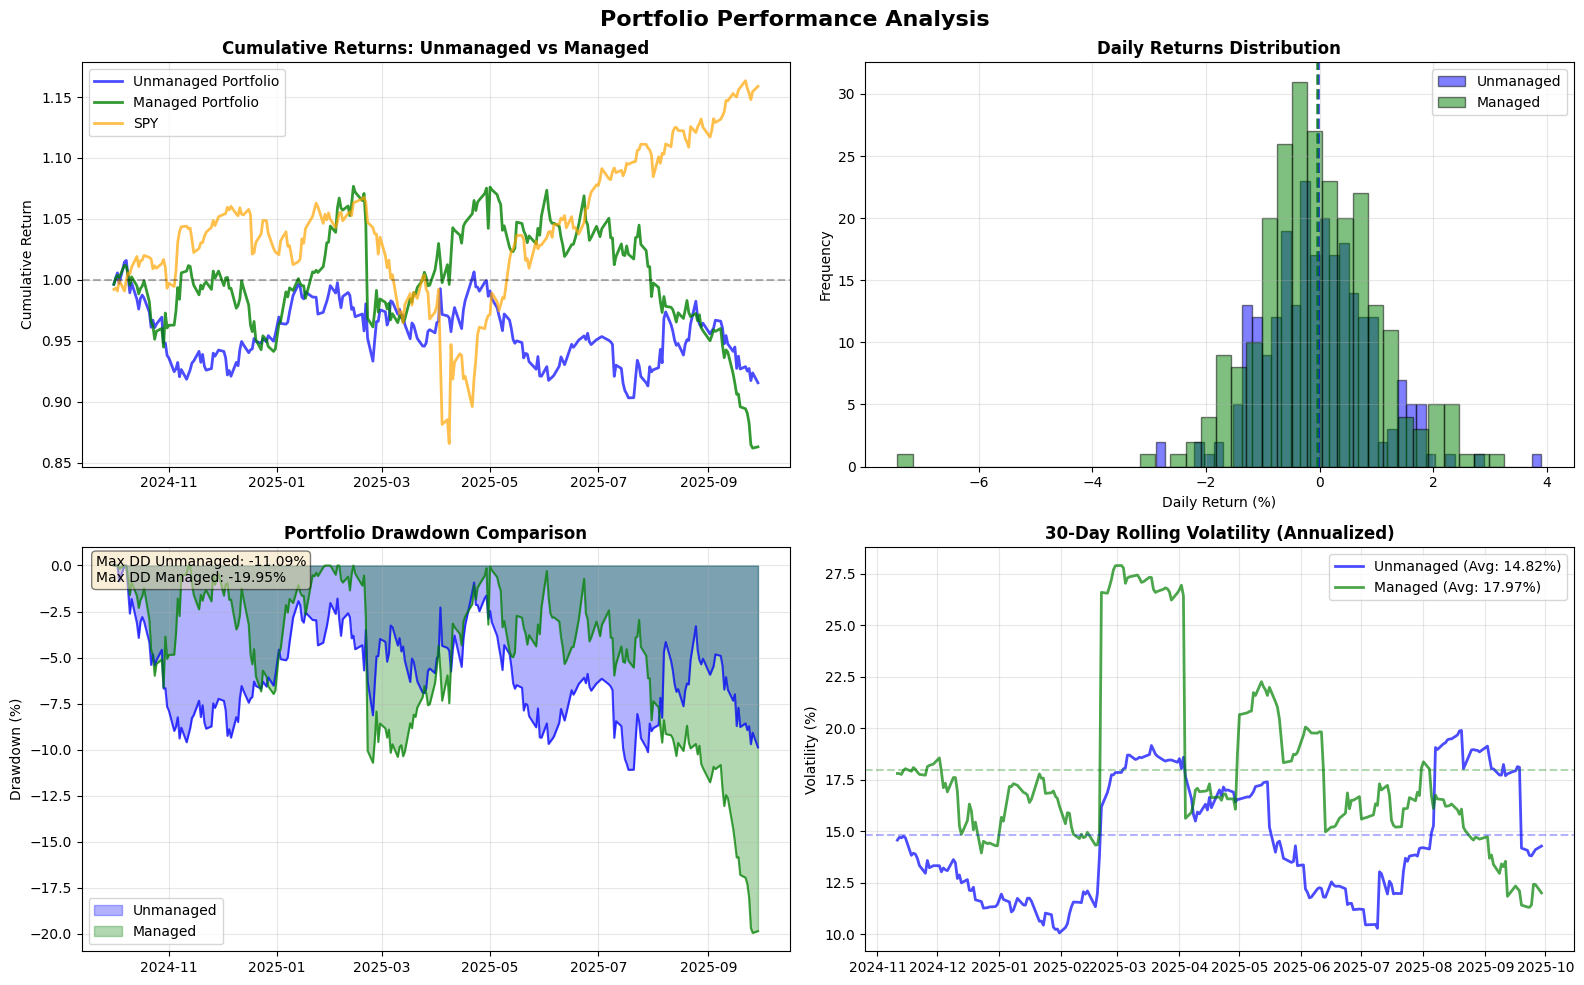

In [122]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance Analysis', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs Managed vs SPY
ax1 = axes[0, 0]
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()
managed_cumulative = (1 + managed_daily_returns).cumprod()

ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Unmanaged Portfolio', alpha=0.7)
ax1.plot(managed_cumulative.index, managed_cumulative.values, 
         linewidth=2, color='green', label='Managed Portfolio', alpha=0.8)

if "SPY" in ticker_closes:
    spy_cumulative = (1 + spy_returns).cumprod()
    aligned_spy = spy_cumulative.reindex(portfolio_cumulative.index).ffill()
    ax1.plot(portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns: Unmanaged vs Managed', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution - Comparison
ax2 = axes[0, 1]
ax2.hist(portfolio_daily_returns.dropna() * 100, bins=40, alpha=0.5, 
         color='blue', edgecolor='black', label='Unmanaged')
ax2.hist(managed_daily_returns.dropna() * 100, bins=40, alpha=0.5, 
         color='green', edgecolor='black', label='Managed')
ax2.axvline(portfolio_daily_returns.mean() * 100, color='blue', 
            linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(managed_daily_returns.mean() * 100, color='green', 
            linestyle='--', linewidth=2, alpha=0.7)
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart - Comparison
ax3 = axes[1, 0]
running_max = portfolio_cumulative.cummax()
drawdown = (portfolio_cumulative / running_max - 1.0) * 100
managed_running_max = managed_cumulative.cummax()
managed_drawdown = (managed_cumulative / managed_running_max - 1.0) * 100

ax3.fill_between(drawdown.index, drawdown.values, 0, 
                  alpha=0.3, color='blue', label='Unmanaged')
ax3.plot(drawdown.index, drawdown.values, linewidth=1.5, color='blue', alpha=0.7)
ax3.fill_between(managed_drawdown.index, managed_drawdown.values, 0, 
                  alpha=0.3, color='green', label='Managed')
ax3.plot(managed_drawdown.index, managed_drawdown.values, linewidth=1.5, color='green', alpha=0.7)

ax3.set_title('Portfolio Drawdown Comparison', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
ax3.legend()
max_dd = drawdown.min()
managed_max_dd = managed_drawdown.min()
ax3.text(0.02, 0.98, f'Max DD Unmanaged: {max_dd:.2f}%\nMax DD Managed: {managed_max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day) - Comparison
ax4 = axes[1, 1]
rolling_vol = portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100
managed_rolling_vol = managed_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100

ax4.plot(rolling_vol.index, rolling_vol.values, linewidth=2, color='blue', 
         label=f'Unmanaged (Avg: {annual_volatility*100:.2f}%)', alpha=0.7)
ax4.plot(managed_rolling_vol.index, managed_rolling_vol.values, linewidth=2, color='green',
         label=f'Managed (Avg: {managed_annual_volatility*100:.2f}%)', alpha=0.7)
ax4.axhline(y=annual_volatility * 100, color='blue', linestyle='--', alpha=0.3)
ax4.axhline(y=managed_annual_volatility * 100, color='green', linestyle='--', alpha=0.3)
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


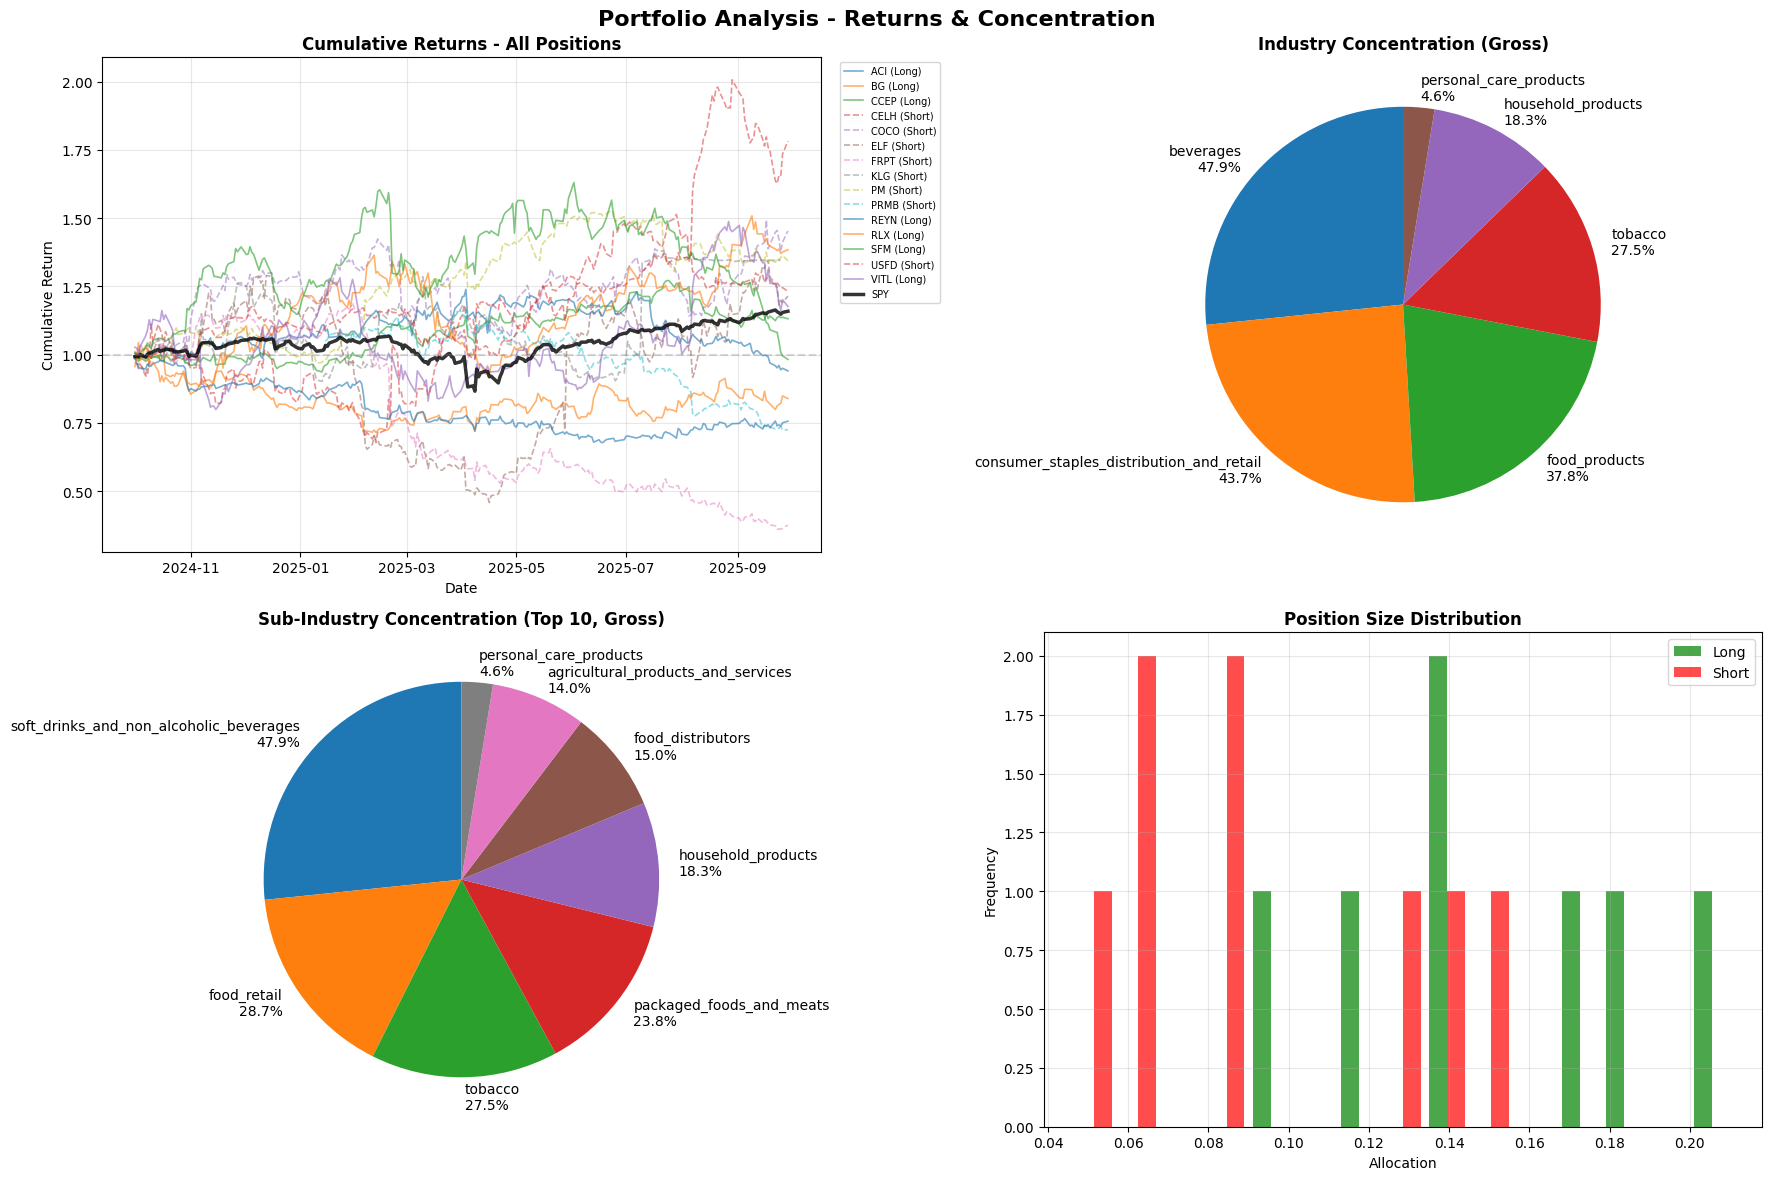

In [123]:
industry_data = {}
sub_industry_data = {}

with MarketSession() as session:
    for ticker in weights.keys():
        ticker_obj = session.query(Ticker).filter(Ticker.ticker == ticker.upper()).first()
        if ticker_obj:
            industry_data[ticker] = ticker_obj.industry
            sub_industry_data[ticker] = ticker_obj.sub_industry

# Calculate concentration by industry and sub-industry
industry_concentration = {}
sub_industry_concentration = {}

for ticker, allocation in weights.items():
    abs_allocation = abs(allocation)
    
    industry = industry_data.get(ticker, 'Unknown')
    if industry:
        industry_concentration[industry] = industry_concentration.get(industry, 0) + abs_allocation
    
    sub_industry = sub_industry_data.get(ticker, 'Unknown')
    if sub_industry:
        sub_industry_concentration[sub_industry] = sub_industry_concentration.get(sub_industry, 0) + abs_allocation

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Portfolio Analysis - Returns & Concentration', fontsize=16, fontweight='bold')

# 1. Cumulative returns of all positions
ax1 = axes[0, 0]
for ticker in sorted(weights.keys()):
    if ticker in ticker_price_returns:
        cumulative_returns = (1 + ticker_price_returns[ticker]).cumprod()
        position_type = portfolio[ticker]['position']
        
        if position_type.lower() == 'short':
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    linestyle='--', alpha=0.5, linewidth=1.2, label=f"{ticker} (Short)")
        else:
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    alpha=0.6, linewidth=1.2, label=f"{ticker} (Long)")

if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    spy_cumulative = (1 + spy_returns).cumprod()
    ax1.plot(spy_cumulative.index, spy_cumulative.values, 
            linewidth=2.5, color='black', label='SPY', alpha=0.8)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Returns - All Positions', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax1.grid(True, alpha=0.3)

# 2. Industry concentration pie chart
ax2 = axes[0, 1]
if industry_concentration:
    labels = [f"{k}\n{v:.1%}" for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    sizes = [v for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    ax2.pie(sizes, labels=labels, autopct='', startangle=90)
    ax2.set_title('Industry Concentration (Gross)', fontweight='bold')

# 3. Sub-industry concentration pie chart
ax3 = axes[1, 0]
if sub_industry_concentration:
    # Limit to top 10 for readability
    sorted_sub = sorted(sub_industry_concentration.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = [f"{k}\n{v:.1%}" for k, v in sorted_sub]
    sizes = [v for k, v in sorted_sub]
    ax3.pie(sizes, labels=labels, autopct='', startangle=90)
    ax3.set_title('Sub-Industry Concentration (Top 10, Gross)', fontweight='bold')

# 4. Position size distribution
ax4 = axes[1, 1]
long_weights = [v for v in weights.values() if v > 0]
short_weights = [abs(v) for v in weights.values() if v < 0]
ax4.hist([long_weights, short_weights], bins=15, label=['Long', 'Short'], alpha=0.7, color=['green', 'red'])
ax4.set_title('Position Size Distribution', fontweight='bold')
ax4.set_xlabel('Allocation')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


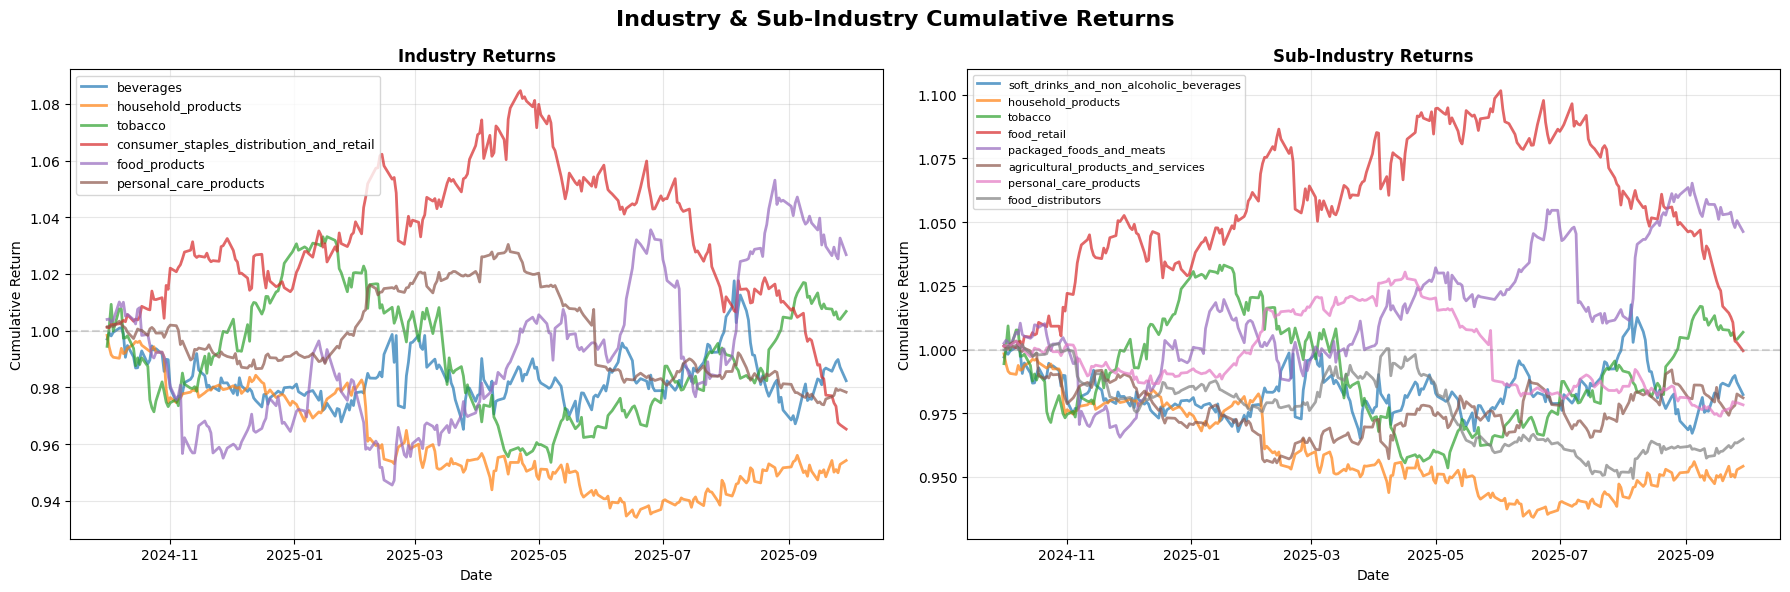

In [124]:
# Calculate industry and sub-industry level returns
# Group tickers by industry
industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        industry = industry_data.get(ticker)
        if industry:
            if industry not in industry_groups:
                industry_groups[industry] = {}
            industry_groups[industry][ticker] = allocation

# Group tickers by sub-industry
sub_industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        sub_industry = sub_industry_data.get(ticker)
        if sub_industry:
            if sub_industry not in sub_industry_groups:
                sub_industry_groups[sub_industry] = {}
            sub_industry_groups[sub_industry][ticker] = allocation

# Calculate industry-level returns
industry_returns = {}
for industry, tickers_weights in industry_groups.items():
    industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    industry_returns[industry] = industry_daily_returns

# Calculate sub-industry-level returns
sub_industry_returns = {}
for sub_industry, tickers_weights in sub_industry_groups.items():
    sub_industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    sub_industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        sub_industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    sub_industry_returns[sub_industry] = sub_industry_daily_returns

# Create two graphs
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Industry & Sub-Industry Cumulative Returns', fontsize=16, fontweight='bold')

# 1. Industry returns
ax1 = axes[0]
for industry, returns in industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax1.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=industry)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Industry Returns', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Sub-industry returns
ax2 = axes[1]
for sub_industry, returns in sub_industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax2.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=sub_industry)

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax2.set_title('Sub-Industry Returns', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Fetching 2 years of prior data: 2022-09-30 to 2024-09-30
Successfully fetched prior data for 15 tickers

PRIOR PERIOD (2022-09-30 to 2024-09-30) PERFORMANCE METRICS
Annualized Return:        4.49%
Annual Volatility:       15.27%
Sharpe Ratio:              0.11
Alpha vs SPY:             0.24%
Beta vs SPY:               0.07


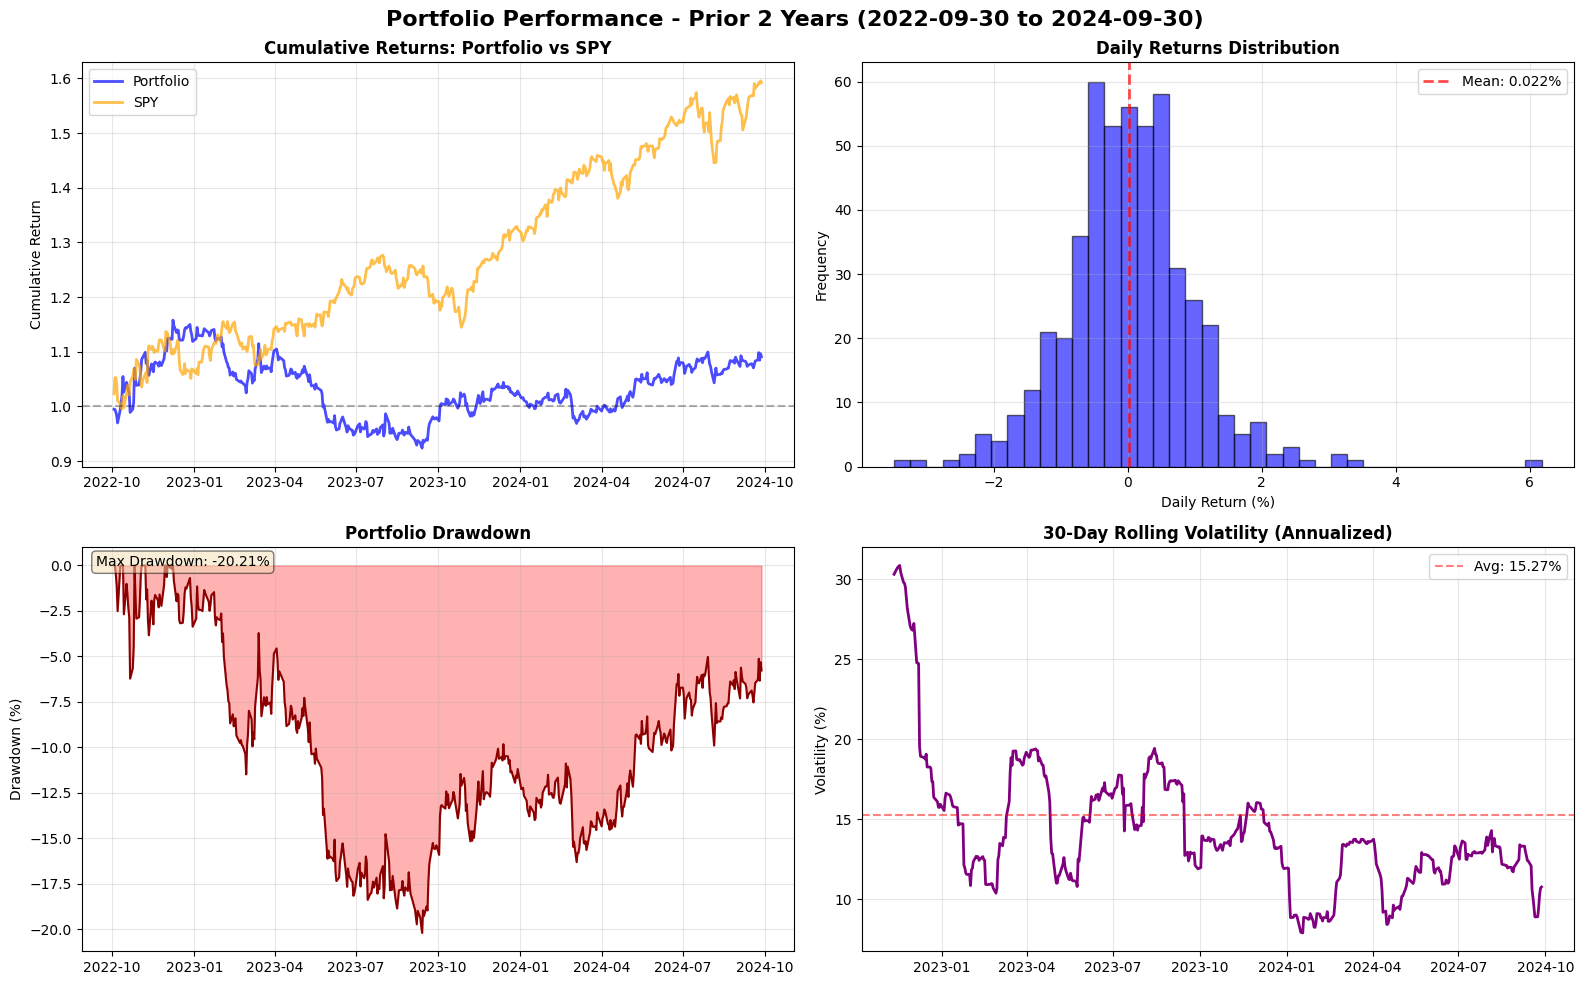

In [125]:
# Graph 2 years of portfolio returns BEFORE the start date
# Start date is 2024-09-30, so we want data from 2022-09-30 to 2024-09-30

prior_start_date = datetime(2022, 9, 30)
prior_end_date = datetime(2024, 9, 30)

prior_start_str = prior_start_date.strftime('%Y-%m-%d')
prior_end_str = prior_end_date.strftime('%Y-%m-%d')

print(f"Fetching 2 years of prior data: {prior_start_str} to {prior_end_str}")

# Fetch bulk price data for the prior period
prior_ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    prior_start_str, 
    prior_end_str, 
    frequency='daily'
)

print(f"Successfully fetched prior data for {len(prior_ticker_closes)} tickers\n")

# Calculate prior period returns
prior_ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(prior_ticker_closes[t])
    for t in weights if t in prior_ticker_closes
}

# Calculate portfolio daily returns for prior period
prior_portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    prior_ticker_price_returns, 
    weights, 
    dropna=False,  
)

# Calculate performance metrics for prior period
prior_annualized_return = ReturnsCalculator.annualized_return(prior_portfolio_daily_returns, trading_days=252)
prior_annual_volatility = RiskCalculator.annualized_volatility(prior_portfolio_daily_returns, trading_days=252)
prior_sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    prior_portfolio_daily_returns, 
    periods_per_year=252
)

# Calculate alpha and beta vs SPY for prior period
if "SPY" in prior_ticker_closes:
    prior_spy_returns = ReturnsCalculator.daily_price_returns(prior_ticker_closes["SPY"])
    prior_alpha = PerformanceCalculator.alpha_jensen(
        prior_portfolio_daily_returns,
        prior_spy_returns,
        periods_per_year=252
    )
    prior_beta = RiskCalculator.beta(
        asset_daily_returns=prior_portfolio_daily_returns,
        market_daily_returns=prior_spy_returns
    )
else:
    prior_alpha = np.nan
    prior_beta = np.nan

# Print prior period metrics
print("=" * 60)
print("PRIOR PERIOD (2022-09-30 to 2024-09-30) PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {prior_annualized_return:>8.2%}")
print(f"Annual Volatility:     {prior_annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {prior_sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {prior_alpha:>8.2%}")
print(f"Beta vs SPY:           {prior_beta:>8.2f}")
print("=" * 60)

# Plot prior period cumulative returns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance - Prior 2 Years (2022-09-30 to 2024-09-30)', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs SPY
ax1 = axes[0, 0]
prior_portfolio_cumulative = (1 + prior_portfolio_daily_returns).cumprod()

ax1.plot(prior_portfolio_cumulative.index, prior_portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Portfolio', alpha=0.7)

if "SPY" in prior_ticker_closes:
    prior_spy_cumulative = (1 + prior_spy_returns).cumprod()
    aligned_spy = prior_spy_cumulative.reindex(prior_portfolio_cumulative.index).ffill()
    ax1.plot(prior_portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns: Portfolio vs SPY', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution
ax2 = axes[0, 1]
ax2.hist(prior_portfolio_daily_returns.dropna() * 100, bins=40, alpha=0.6, 
         color='blue', edgecolor='black')
ax2.axvline(prior_portfolio_daily_returns.mean() * 100, color='red', 
            linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {prior_portfolio_daily_returns.mean()*100:.3f}%')
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart
ax3 = axes[1, 0]
prior_running_max = prior_portfolio_cumulative.cummax()
prior_drawdown = (prior_portfolio_cumulative / prior_running_max - 1.0) * 100

ax3.fill_between(prior_drawdown.index, prior_drawdown.values, 0, 
                  alpha=0.3, color='red')
ax3.plot(prior_drawdown.index, prior_drawdown.values, linewidth=1.5, color='darkred')

ax3.set_title('Portfolio Drawdown', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
prior_max_dd = prior_drawdown.min()
ax3.text(0.02, 0.98, f'Max Drawdown: {prior_max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day)
ax4 = axes[1, 1]
prior_rolling_vol = prior_portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100

ax4.plot(prior_rolling_vol.index, prior_rolling_vol.values, linewidth=2, color='purple')
ax4.axhline(y=prior_annual_volatility * 100, color='red', linestyle='--', alpha=0.5, 
            label=f'Avg: {prior_annual_volatility*100:.2f}%')
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()